# ESACT 2026: Hybrid modelling workshop

In [24]:
##################################### Cell 0: Libraries #############################################################
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import random
import time
import os
import requests
import re
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import itertools
from pathlib import Path
from tqdm import tqdm
import torch._dynamo
import math
import fnmatch

torch._dynamo.config.recompile_limit = 100
torch._dynamo.config.cache_size_limit = 200

In [25]:
HMOD_FILE = "HybCHO_new.hmod"
DATA_FILE = "CHOdata.csv"
# For all following parameters, if lists are left empty, program tries to read them
# from hmod file. If they are not there, probably there will be an error.
CONTROLS = ["Feed", "Induc"] # For example, ["Feed", "Induc"]
NN_INPUTS = ["VCD", "EGLC", "ELAC", "EGLN", "EGLU", "ENH4", "mAB", "Induc"]
NN_INPUT_MAXES = [24.113, 1845.401, 21.966, 21.057, 1.994, 37.887, 1366.103, 1.0]
NN_OUTPUTS = ["mu", "vGLC", "vLAC", "vGLN", "vGLU", "vNH4", "vmAB"] # For example, ["rX, rV"]
NN_INNER_LAYERS = [8] # For example, [2, 3]
activation = "tanh"
activation_output = None # "relu" or None
weight_dropout_rate = 0.2
trainbatch = [8]
valbatch = [2, 3, 4, 5, 6, 7]
testbatch = [0, 1]
lr, weight_decay, epochs = 1e-3, 1e-4, 10000
NN_WEIGHTS_STD = 0.01
train_minibatch_rate = 0.90
weight_dropout_rate = 0.15
model_selection_criterion = "validation" # "training" or "validation"
sd_from_sd_column = False

In [26]:
class Species:
    def __init__(self, name, compartment, ind):
        self.name = name
        self.ind = ind
        self.compartment = compartment

class Parameter:
    def __init__(self, name, value):
        self.name = name
        self.value = value

class Compartment:
    def __init__(self, name):
        self.name = name

class Reaction:
    def __init__(self, name, rate_expr, stoich_row_expr):
        self.name = name
        self.rate_expr = rate_expr
        self.stoich_row_expr = stoich_row_expr

class RateRule:
    def __init__(self, name, rate_expr):
        self.name = f"change_{name}"
        self.subj = name
        self.rate_expr = rate_expr

class AssignRule:
    def __init__(self, name, expr):
        self.name = name
        self.expr = expr

class Control:
    def __init__(self, name):
        self.name = name

class NetworkInput:
    def __init__(self, name, max_value):
        self.name = name
        self.max_value = max_value

class NetworkOutput:
    def __init__(self, name):
        self.name = name

class Network:
    def __init__(self, layers_str):
        self.layers = [int(v) for v in layers_str.split(" ")]

In [27]:
def strip_model_name(s):
    first_point_pos = s.find('.')
    if first_point_pos != -1:
        return s[first_point_pos + 1:]
    else:
        return s

def get_name_val(s):
    s = s.replace(";", "")
    name, val = s.split("=")
    return name.strip(), val.strip().replace("'", "").replace('"', '')

In [28]:
class HmodStringReader:
    def __init__(self):
        self.identifier_str = None
        self.info = []

    def get_info_line(self, s):
        s = strip_model_name(s)
        return get_name_val(s)

    def finish(self, name_str, val_str, identifier_str):
        self.identifier_str = identifier_str
        old_info = self.info
        self.info = [[name_str, val_str]]
        return old_info

    def proceed_string(self, s):
        if "=" not in s:
            return self.finish("", "", "")
        name_str, val_str = get_name_val(strip_model_name(s))
        last_point_pos = name_str.rfind(".")
        if last_point_pos == -1:
            identifier_str = name_str
        else:
            identifier_str = name_str[:last_point_pos]
        if self.identifier_str is None:
            self.identifier_str = identifier_str
        if self.identifier_str != identifier_str:
            return self.finish(name_str, val_str, identifier_str)
        else:
            self.info.append([name_str, val_str])



In [29]:
def read_hmod(filename):
    with open(filename, 'r') as f:
        species = []
        reactions = []
        compartments = []
        parameters = []
        rate_rules = []
        assign_rules = []
        controls = []
        network = None
        network_inputs = []
        network_outputs = []
        TAU = None
        hmod_reader = HmodStringReader()
        species_counter = 0
        for line in f:
            line = line.strip()
            if line and not line.startswith("%"):
                res = hmod_reader.proceed_string(line)
                if res:
                    if res[0][0].startswith("species("):
                        sp_name = None
                        c_name = None
                        for name, val in res:
                            if name.endswith("id"):
                                sp_name = val
                            elif name.endswith("compartment"):
                                c_name = val
                        new_sp = Species(sp_name, c_name, species_counter)
                        species.append(new_sp)
                        species_counter += 1
                    elif res[0][0].startswith("compartments("):
                        c_name = None
                        for name, val in res:
                            if name.endswith("id"):
                                c_name = val.replace("'", "").replace('"', '')
                        new_comp = Compartment(c_name)
                        compartments.append(new_comp)
                    elif res[0][0].startswith("parameters("):
                        p_name = None
                        p_val = None
                        for name, val in res:
                            if name.endswith("id"):
                                p_name = val
                            elif name.endswith("val"):
                                p_val = val
                        new_param = Parameter(p_name, p_val)
                        parameters.append(new_param)
                    elif res[0][0].startswith("reaction("):
                        re_name = None
                        stoich_row = None
                        rate_expr = None
                        for name, val in res:
                            if name.endswith("id"):
                                re_name = val
                            elif name.endswith("rate"):
                                rate_expr = val
                            elif name.endswith(re_name):
                                stoich_row = val
                        new_reac = Reaction(re_name, rate_expr, stoich_row)
                        reactions.append(new_reac)
                    elif res[0][0].startswith("raterules("):
                        rr_name = None
                        rate_expr = None
                        for name, val in res:
                            if name.endswith("id"):
                                rr_name = val
                            elif name.endswith("val"):
                                rate_expr = val
                        if rate_expr != "0":
                            new_rr = RateRule(rr_name, rate_expr)
                            rate_rules.append(new_rr)
                    elif res[0][0].startswith("ruleAss("):
                        ar_name = None
                        expr = None
                        for name, val in res:
                            if name.endswith("id"):
                                ar_name = val
                            elif name.endswith("val"):
                                expr = val
                        new_ar = AssignRule(ar_name, expr)
                        assign_rules.append(new_ar)
                    elif res[0][0].startswith("control(") and not CONTROLS:
                        c_name = None
                        for name, val in res:
                            if name.endswith("id"):
                                c_name = val
                        new_c = Control(c_name)
                        controls.append(new_c)
                    elif res[0][0] == "mlm.options" and not NN_INNER_LAYERS:
                        val = res[0][1]
                        pos_first = val.find("[")
                        pos_last = val.rfind("]")
                        arr_str = val[pos_first + 1: pos_last]
                        network = Network(arr_str)
                    elif res[0][0] == "time.TAU":
                        TAU = float(res[0][1])
                    elif res[0][0].startswith("mlm.x(") and not NN_INPUTS:
                        inp_name = None
                        inp_max = None
                        for name, val in res:
                            if name.endswith("val"):
                                inp_name = val
                            elif name.endswith("max"):
                                inp_max = val
                        new_inp = NetworkInput(inp_name, inp_max)
                        network_inputs.append(new_inp)
                    elif res[0][0].startswith("mlm.y(") and not NN_OUTPUTS:
                        out_name = None
                        for name, val in res:
                            if name.endswith("id"):
                                out_name = val
                        new_out = NetworkOutput(out_name)
                        network_outputs.append(new_out)
    for control in CONTROLS:
        new_c = Control(control)
        controls.append(new_c)
    for inp, inp_max in zip(NN_INPUTS, NN_INPUT_MAXES):
        new_inp = NetworkInput(inp, str(inp_max))
        network_inputs.append(new_inp)
    for out_name in NN_OUTPUTS:
        new_out = NetworkOutput(out_name)
        network_outputs.append(new_out)
    if NN_INNER_LAYERS:
        network = Network(" ".join([str(v) for v in NN_INNER_LAYERS]))
    return species, reactions, compartments, parameters, rate_rules, assign_rules, controls, network, network_inputs, network_outputs, TAU




In [30]:
def generate_S_matrix_str(reactions):
    strs = ", ".join([reaction.stoich_row_expr for reaction in reactions])
    return f"[{strs}]"

In [31]:
def get_var_names(expression_str):
    expression_str = expression_str.replace("^", "**")
    vars = re.findall(r"[a-zA-Z_][a-zA-Z0-9_]*", expression_str)
    vars = list(set(vars)) # exclude repetitions
    return vars

def generate_params_independant(parameters, assign_rules, network_outputs):
    assign_names = [assign_rule.name for assign_rule in assign_rules]
    output_names = [output.name for output in network_outputs]
    param_independants = [param for param in parameters
                           if (param.name not in assign_names) and
                              (param.name not in output_names)]
    s = ""
    for param in param_independants:
        s += f"    {param.name} = {param.value}\n"
    return s

def get_global_parent_names(species,
                            compartments,
                            controls,
                            network_outputs,
                            parameters,
                            assign_rules):
    assign_names = [assign_rule.name for assign_rule in assign_rules]
    param_independants = [param.name for param in parameters if param.name not in assign_names]
    names = param_independants
    names.extend([spec.name for spec in species])
    names.extend([comp.name for comp in compartments])
    names.extend([control.name for control in controls])
    names.extend([out.name for out in network_outputs])
    names = list(set(names)) #remove not unique
    return names

class Node:
    def __init__(self, name, val, global_parents_names):
        self.name = name
        self.val = val
        self.parents_names = get_var_names(val)
        self.parents = {}
        self.children = {}
        self.parents_levels = {name: (0 if name in global_parents_names else -1) for name in self.parents_names}
        self.set_level()
    def set_level(self):
        if self.parents_levels == {}:
            self.level = 0
        else:
            self.level = (max(self.parents_levels.values()) + 1) if not (-1 in self.parents_levels.values()) else -1

def populate_nodes(parent_names, assign_rules, rate_rules, reactions):
    nodes = {}
    for assign_rule in assign_rules:
        nodes[assign_rule.name] = Node(assign_rule.name, assign_rule.expr, parent_names)
    for rate_rule in rate_rules:
        nodes[rate_rule.name] = Node(rate_rule.name, rate_rule.rate_expr, parent_names)
    for reaction in reactions:
        nodes[reaction.name] = Node(reaction.name, reaction.rate_expr, parent_names)
    for name, node in nodes.items():
        for parent_name in node.parents_names:
            if parent_name in nodes:
                node.parents[parent_name] = nodes[parent_name]
                nodes[parent_name].children[name] = node
    number_without_level = 1
    iteration_num = 0
    while number_without_level > 0:
        number_without_level = 0
        for name, node in nodes.items():
            if node.level == -1:
                if iteration_num > 1000:
                    print("Problem in hmod file definition of", name)
                for parent_name in node.parents_names:
                    if parent_name in nodes and nodes[parent_name].level != -1:
                        node.parents_levels[parent_name] = nodes[parent_name].level
                node.set_level()
                if node.level == -1:
                    number_without_level += 1
        iteration_num += 1
    nodes = {k: v for k, v in sorted(nodes.items(), key=lambda item: item[1].level)} #sort dict by level
    return nodes


In [32]:
def generate_rules_expressions(nodes):
    s = ""
    for name, node in nodes.items():
        s += f"    {name} = {node.val}\n"
    return s

In [33]:
def generate_state_decomposition(species, compartments, rate_rules):
    rate_rules_outputs = [rule.subj for rule in rate_rules]
    compartments_names = [comp.name for comp in compartments if comp.name in rate_rules_outputs]
    species_names = [sp.name for sp in species]
    state_names = species_names + compartments_names
    state_names_str = ", ".join(state_names)
    return f"({state_names_str},) = state.T"

In [34]:
def generate_controls_decomposition(controls):
    control_names = [control.name for control in controls]
    control_names_str = ", ".join(control_names)
    return f"({control_names_str},) = controls.T"

In [35]:
def generate_target_max(network_inputs):
    target_maxes = [network_input.max_value for network_input in network_inputs]
    target_maxes_str = ", ".join(target_maxes)
    return f"torch.tensor([{target_maxes_str}])"


In [36]:
def generate_species_max(network_inputs, species):
    target_maxes = {network_input.name: network_input.max_value for network_input in network_inputs}
    species_maxes = [target_maxes[sp.name] for sp in species]
    species_maxes_str = ", ".join(species_maxes)
    return f"torch.tensor([{species_maxes_str}])"

In [37]:
def generate_network_inputs_str(network_inputs):
    names = [network_input.name for network_input in network_inputs]
    names_str = ", ".join(names)
    return f"torch.stack(({names_str},)).T / target_max"

In [38]:
def generate_network_outputs_str(network_outputs):
    names = [network_output.name for network_output in network_outputs]
    res_str = ", ".join(names)
    return f"({res_str},)"

In [39]:
def generate_reaction_rates_matrix(reactions):
    names = [reaction.name for reaction in reactions]
    names_str = ", ".join(names)
    return f"torch.stack(({names_str},))"

In [40]:
def generate_species_tuple(species):
    names = [species.name for species in species]
    names_str = ", ".join(names)
    return f"({names_str},)"

In [41]:
def generate_dilution_terms(species, compartments, rate_rules):
    rate_rules_outputs = [rule.subj for rule in rate_rules]
    compartments_names = [comp.name for comp in compartments if comp.name in rate_rules_outputs]
    s = ""
    rate_rules_dict = {rule.subj: rule.name for rule in rate_rules}
    for compartment_name in compartments_names:
        species_this_compartment = []
        for ind, sp in enumerate(species):
            if sp.compartment == compartment_name:
                species_this_compartment.append(ind)
        rate_rule_name = rate_rules_dict[compartment_name]
        ind_str = ", ".join([str(ind) for ind in species_this_compartment])
        s += f"    for i in ({ind_str},):\n"
        s += f"        ODEs[i] = ODEs[i] - {rate_rule_name} / {compartment_name} * species_tuple[i]\n"
    return s

In [42]:
def generate_ODEs_rate_rules_if_any(rate_rules, compartments):
    rate_rules_outputs = [rule.subj for rule in rate_rules]
    compartments_names = [comp.name for comp in compartments if comp.name in rate_rules_outputs]
    rate_rules_dict = {rule.subj: rule.name for rule in rate_rules}
    rr = [rate_rules_dict[compartment_name] for compartment_name in compartments_names]
    if rr:
        rr_str = ", ".join(rr)
        result = f"""
    ODEs_compartments = torch.stack(({rr_str},))
    ODEs = torch.vstack((ODEs, ODEs_compartments))"""
    else:
        result = ""
    return result


In [43]:
def get_rate_rules_species(species, rate_rules):
    rate_rules_outputs = {rule.subj: rule.name for rule in rate_rules}
    species_names = [sp.name for sp in species]
    species_rate_rules_dict = {}
    for i, name in enumerate(species_names):
        if name in rate_rules_outputs.keys():
            species_rate_rules_dict[i] = rate_rules_outputs[name]
    return species_rate_rules_dict

In [44]:
def generate_species_ODEs(species, compartments, reactions, rate_rules):
    rate_rules_species = get_rate_rules_species(species, rate_rules)
    if len(reactions) > 0:
        result = f"""
    S = torch.tensor({generate_S_matrix_str(reactions)}, dtype = torch.float)     # [[reaction 1 stoichiometry],
                                                                                  #  [reaction 2 stoichiometry]]
    rates = {generate_reaction_rates_matrix(reactions)}     # [[rate1_batch1, rate1_batch2...],
                                                            #  [rate2_batch1, rate2_batch2...]]

    ODEs = S.T @ rates     # [[rA_batch1, rA_batch2...],
                           #  [rB_batch1, rB_batch2...]]
{generate_dilution_terms(species, compartments, rate_rules)}     # modify ODEs
"""
        if len(rate_rules_species) > 0:
            for i, expr in rate_rules_species.items():
                result += f"""
        ODEs[{i}] = {expr}"""
        return result
    else:
        rr_str = ", ".join(rate_rules_species.values())
        result = f"""
    ODEs = torch.stack(({rr_str},))
"""
        return result



In [45]:
def generate_solve_ode_str_and_NN(filename):
    (species,
    reactions,
    compartments,
    parameters,
    rate_rules,
    assign_rules,
    controls,
    network,
    network_inputs,
    network_outputs,
    TAU) = read_hmod(filename)
    parent_names = get_global_parent_names(species,
                            compartments,
                            controls,
                            network_outputs,
                            parameters,
                            assign_rules)
    nodes = populate_nodes(parent_names, assign_rules, rate_rules, reactions)

    ode_fun_str = f"""
target_max = {generate_target_max(network_inputs)}
species_max = {generate_species_max(network_inputs, species)}

@torch.compile(fullgraph=False)
def solve_ode(t, state, model, target_max, controls):
{generate_params_independant(parameters, assign_rules, network_outputs)}
    {generate_state_decomposition(species, compartments, rate_rules)}     # (X, V,) = state.T
    {generate_controls_decomposition(controls)}     # (Feed,) = controls.T
    species_tuple = {generate_species_tuple(species)}     # [[A_batch1, A_batch2...],
                                                        #  [B_batch1, B_batch2...]]
    model_input = {generate_network_inputs_str(network_inputs)}
    outputs = model(model_input)
    {generate_network_outputs_str(network_outputs)} = outputs.T     # (rX, rV,) = outputs.T

{generate_rules_expressions(nodes)}     # assignment rules, rate rules, reaction kinetics rules
{generate_species_ODEs(species, compartments, reactions, rate_rules)}

{generate_ODEs_rate_rules_if_any(rate_rules, compartments)}

    return ODEs.T"""
    print(ode_fun_str)
    inputs_num = len(network_inputs)
    outputs_num = len(network_outputs)
    species_names = [species.name for species in species]
    controls_names = [control.name for control in controls]
    volumes_names = [compartment.name for compartment in compartments]
    return ode_fun_str, network, TAU, inputs_num, outputs_num, species_names, controls_names, volumes_names


In [46]:
################################### Cell 5: ODE Function for Hybrid-semiparametric ########################################
ode_fun_str, network, TAU, inputs_num, outputs_num,\
species_names, controls_names, volumes_names = generate_solve_ode_str_and_NN(HMOD_FILE)
exec(ode_fun_str)



target_max = torch.tensor([24.113, 1845.401, 21.966, 21.057, 1.994, 37.887, 1366.103, 1.0])
species_max = torch.tensor([24.113, 1845.401, 21.966, 21.057, 1.994, 37.887, 1366.103])

@torch.compile(fullgraph=False)
def solve_ode(t, state, model, target_max, controls):
    GLCfeed = 1893
    GLNfeed = 24

    (VCD, EGLC, ELAC, EGLN, EGLU, ENH4, mAB, V,) = state.T     # (X, V,) = state.T
    (Feed, Induc,) = controls.T     # (Feed,) = controls.T
    species_tuple = (VCD, EGLC, ELAC, EGLN, EGLU, ENH4, mAB,)     # [[A_batch1, A_batch2...],
                                                        #  [B_batch1, B_batch2...]]
    model_input = torch.stack((VCD, EGLC, ELAC, EGLN, EGLU, ENH4, mAB, Induc,)).T / target_max
    outputs = model(model_input)
    (mu, vGLC, vLAC, vGLN, vGLU, vNH4, vmAB,) = outputs.T     # (rX, rV,) = outputs.T

    D = Feed/V
    change_VCD = mu*VCD - D*VCD
    change_EGLC = -vGLC*VCD - D*EGLC + D*GLCfeed
    change_ELAC = -vLAC*VCD - D*ELAC
    change_EGLN = -vGLN*VCD

In [47]:
################################ Cell 6: Hybrid semiparametric model- RK 4 solver #######################################

@torch.compile(fullgraph=False)
def solve_ode_semi_parametric(ode_func, state, t, tf, h, model, target_max, controls):

    #define time space as beginning to end of time step
    n_steps = ((tf - t) / h).to(torch.int64)
    times = t + h * torch.arange(n_steps, device=t.device)

    #times = torch.arange(t, tf, h) #time is tensor and not Python floats

    for t in times:
        #h_current = tf - t

        #add for overshooting control (when tf-t < h), minimum between time step and (final time and current time)
        h_current = torch.minimum(torch.tensor(h, dtype=t.dtype), tf - t) #ensures tensor, compatible with compile

        #Runge-Kutta steps
        k1 = ode_func(t, state, model, target_max, controls)

        k2 = ode_func(t + h_current / 2, state + h_current / 2 * k1, model, target_max,controls)

        k3 = ode_func(t + h_current / 2, state + h_current / 2 * k2, model, target_max, controls)

        k4 = ode_func(t + h_current, state + h_current * k3, model, target_max, controls)

        #update state and time
        state = state + h_current * (k1 / 6 + k2 / 3 + k3 / 3 + k4 / 6) #POSSIBLE ISSUE: iterative loop, updates in loop
        #state = state.detach() #LGnote: Fix 2
        state[state<0] = 0

    return state



In [48]:
def split_df_to_batches(df):
    prev_i = 0
    batches = []
    for i, line in df.iterrows():
        if np.isnan(line.time):
            batch = df[prev_i: i]
            batch.reset_index(drop=True, inplace=True)
            batches.append(batch)
            prev_i = i + 1
    batch = df[prev_i:]
    batch.reset_index(drop=True, inplace=True)
    batches.append(batch)
    return batches

def get_min_time_step(batches):
    min_time_step = float("inf")
    for batch in batches:
        times = np.array(batch["time"])
        time_steps = times[1:] - times[:-1]
        min_time_step = min(min_time_step, np.min(time_steps))
    return min_time_step

def Data_Solutions(data_file, species_names, controls_names, volumes_names, TAU):

    df = pd.read_csv(data_file)
    #pd.set_option('display.max_rows', None)
    batches = split_df_to_batches(df)
    time_label = "time"
    if TAU is None:
        min_time_step = get_min_time_step(batches)
        TAU = min_time_step * 0.5
    columns = df.columns
    for name in controls_names:
        if name not in columns:
            raise Exception(f"Control name {name} is not present in csv file!")
    for name in species_names:
        if name not in columns:
            raise Exception(f"Species name {name} is not present in csv file!")
    sd_species_columns = [f"sd{name}" for name in species_names]
    volumes_columns = [name for name in columns if name in volumes_names]
    len_species = len(species_names)

    for name in sd_species_columns:
        if name not in columns:
            raise Exception(f"Species name {name} is not present in csv file!")
    target_np = np.array([batch[species_names].values for batch in batches], dtype=np.float32)
    target_data = torch.from_numpy(target_np)

    target_data0 = target_data[:, 0, :]

    stds_for_data_np = np.array([batch[sd_species_columns].values for batch in batches], dtype=np.float32)
    stds_for_data = torch.from_numpy(stds_for_data_np)

    volumes_np = np.array([batch[volumes_columns].values for batch in batches], dtype=np.float32)
    volumes_data = torch.from_numpy(volumes_np)

    controls_sequence_np = np.array([batch[controls_names].values for batch in batches], dtype=np.float32)
    controls_sequence = torch.from_numpy(controls_sequence_np)

    time_data = torch.tensor(batches[0][time_label])

    batch_numbers = list(range(len(batches)))

    return TAU, target_data, volumes_data, controls_sequence, stds_for_data,\
    target_data0, time_data, batch_numbers, len_species

In [49]:
######################################## Cell 7: Feed-forward neural network (FFNN) #########################################

def set_global_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)

set_global_seed(1234)

class FFNN(nn.Module):
  def __init__(self, input_dim, hidden_layers, output_dim, activation, activation_output=activation_output):

      super(FFNN, self).__init__() #initialize nn.Module
      self.layers = nn.ModuleList()

      ########################################### z^(L) = w^(L) a^(L-1) + b^(L) ########################################

      in_dim = input_dim #26

      #loop for hidden layers
      for h_dim in hidden_layers: # h_dim = 10
          layer = nn.Linear(in_dim, h_dim)    #y (h_dim * 1) = W (h_dim * in_dim) * x (in_dim * 1) + b (h_dim * 1)
          layer.weight.data.normal_(mean=0.0, std=NN_WEIGHTS_STD)
          if layer.bias is not None:
              layer.bias.data.zero_()
          self.layers.append(layer)

          in_dim = h_dim #26 -> 10 -> 10 -> 10

      #output layer (10 -> 25)
      output_layer = nn.Linear(in_dim, output_dim)
      output_layer.weight.data.normal_(mean=0.0, std=0.01)
      if output_layer.bias is not None:
          output_layer.bias.data.zero_()
      self.output_layer = output_layer

      ################################################# sigma( z^(L) ) #################################################

      #set activation function
      activations = {'relu': nn.ReLU, 'tanh': nn.Tanh, 'silu': nn.SiLU, 'gelu': nn.GELU, 'elu': nn.ELU, "leaky_relu": nn.LeakyReLU}

      if activation in activations:
          self.activation = activations[activation]()
      else:
          raise ValueError("Invalid activation function. Choose from 'relu', 'tanh', 'silu', 'gelu' or 'elu'.")
      if activation_output is not None:
          self.output_layer.activation = activations[activation_output]()
      else:
          self.output_layer.activation = lambda x: x

  ################################################# a^(L) = sigma( z^(L) ) #############################################

  def forward(self, x):
      for layer in self.layers:
          x = self.activation(layer(x))
      return self.output_layer.activation(self.output_layer(x))


In [50]:
############################## Cell 8: Function to make predictions with the best model #################################

def predict_with_model(model, target_data, v_data, t_Data, target_max, controls):

  model.eval()

  #torch.set_grad_enabled(False) #LGnote: Fix 5
  prev_grad_state = torch.is_grad_enabled()
  torch.set_grad_enabled(False)

  try:

      exp_preds = []  #list to store state predictions
      preds_v = []    #list to store volume predictions

      #State_0 is the first row of all batches and has shape (batches, 26), contains volume
      state_0 = torch.cat((target_data[:, 0, :], v_data[:, 0, :]), dim=1).detach() #dim=1 -> columns LGnote: Fix 5
      #state_0 = state_0.detach() #LGnote: Fix 1

      state_with_v = state_0

      for i in range(len(t_Data) - 1):

          #Cell 4: Use RK4 method to solve ODE
          state_with_v = solve_ode_semi_parametric(
              ode_func=solve_ode,                   #Cell 3: ODE system
              state=state_with_v,                   #state at i time
              model=model,                          #Cell 9: Use FFNN model
              target_max=target_max,                #Cell 2: Normalize inputs with max concentration
              controls=controls[:, i, :],           #Cell 2: Consider feed rate and feed state (0 or 1)
              t=t_Data[i],                          #Cell 4: Begining of RK4 interval at i time
              tf=t_Data[i+1],                       #Cell 4: End of RK4 interval at i time
              h=TAU)                                  #Cell 1: Time step for RK4

          state_without_v = state_with_v[:, :len_species]
          v = state_with_v[:, len_species:]
          exp_preds.append(state_without_v)         #store concentrations at i time (batches, species)
          preds_v.append(v)                         #store volume at i time (batches,)

      #time added to preds_state (shape: (batches, species) -> (time, batches, species) -> (batches, time, species))
      preds_state = torch.stack(exp_preds, dim=0).permute(1, 0, 2) #add to 1st dim, then permute (convention?)
          #dim=0 -> new dim before existing axes (time, batches, species);
          #dim=1 -> new dim in between existing axes (batches, time, species);
          #dim=2 -> new dim after existing axes (batches, species, time).
      #time added to preds_v (shape: (batches,) -> (time, batches) -> (batches, time))
      preds_v = torch.stack(preds_v, dim=0).T


  finally:
      torch.set_grad_enabled(prev_grad_state)

  return preds_state, preds_v



In [51]:
######################################### Cell 9: Weighted mean square loss ###########################################

@torch.compile(fullgraph=True)
def WMSE(target_data, predicted_data, stds_for_data):

  #during training, data was normalized in solve_ode()
  #actual vs predicted, normalized by std
  weighted_difference = ((target_data - predicted_data) / stds_for_data)

  #square to make all errors positive and "increase" larger ones
  #sum all errors from all batches/times/species (scalar), divide # of target_data elements (all batches/times/species)
  return torch.sum(weighted_difference**2) / target_data.numel()

In [52]:
############################### Cell 10: Stochaistic Reguarization (Weight Dropout) #########################################

def weight_dropout_with_precalculated_values(model, weight_dropout_rate):

  #list of weight tensors in network
  weights = [list(layer.parameters())[0] for layer in itertools.chain(model.layers, [model.output_layer])]

  #len_wights = 26*10 + 10*10 + 10*10 + 10*25 = 260 + 100 + 100 + 250 = 710 -> total weights of network
  len_weights = sum(matrix.numel() for matrix in weights)

  #numels = [260 260+100 260+100+100 260+100+100+250] = [260 360 460 710] -> cumulative sum of weights
  numels = torch.cumsum(torch.tensor([t.numel() for t in weights]), dim=0)

  #hack: elements from 0-th matrix must be decreased by 0 and we set 0 -1'th element
  numels_with_zero = torch.cat((numels, torch.tensor([0])))

  def weight_dropout_fun(model, optimizer, dropout_coef):
    #fast path: no dropout -> just do the optimizer step
    if dropout_coef is None or dropout_coef == 0:
        optimizer.step()
        return

    #list of weight tensors in network
    weights = [list(layer.parameters())[0] for layer in itertools.chain(model.layers, [model.output_layer])]

    #randomly select indexes from list of weights (without replacement)
    #ensure dtype long for indexing later
    num_to_drop = int(len_weights * dropout_coef)
    if num_to_drop <= 0:
        optimizer.step()
        return

    weights_to_dropout = torch.tensor(random.sample(range(len_weights), num_to_drop), dtype=torch.long)

    #identify which matrices those indexes belong to
    matrix_numbers = torch.bucketize(weights_to_dropout, numels, out=None, right=True)

    #shift from local to global indexes inside each layer (still long dtype)
    weights_for_matrices = [weights_to_dropout[matrix_numbers == i] - numels_with_zero[i - 1]
                            for i in range(len(weights))]

    #if no weights chosen for a given matrix, positions entry should be empty tuple
    positions = []
    for w_idxs, matrix in zip(weights_for_matrices, weights):
        if w_idxs.numel() == 0:
            positions.append((torch.tensor([], dtype=torch.long), torch.tensor([], dtype=torch.long)))
        else:
            #unravel_index returns tuple of index tensors (rows, cols)
            pos = torch.unravel_index(w_idxs, matrix.shape)
            positions.append(pos)

    #save weight values that are dropped out
    saved_weights = []
    for matrix, pos in zip(weights, positions):
        #if pos is empty, saved_weights append empty tensor
        if pos[0].numel() == 0:
            saved_weights.append(torch.tensor([], dtype=matrix.dtype))
        else:
            saved_weights.append(matrix[pos].clone())

    #update network using gradients as normally (with dropped weights)
    optimizer.step()

    #restore dropped weights by disabling gradient tracking to change tensors
    with torch.no_grad():
        for matrix, saved, pos in zip(weights, saved_weights, positions):
            if pos[0].numel() == 0:
                continue
            matrix[pos] = saved

  return weight_dropout_fun


In [53]:
##################################### Cell 11: Model and Weight Dropout creation #########################################

nh = network.layers
#initialize model

model = FFNN(input_dim=inputs_num, hidden_layers=nh, output_dim=outputs_num, activation=activation)

weight_dropout = weight_dropout_with_precalculated_values(model, weight_dropout_rate)

def build_model_from_arch_tag(arch_tag):
    # example arch_tag: "25_10_10_10_26_M1"
    parts = arch_tag.split("_")
    layers = list(map(int, parts[:-1]))  # drop M1/M2
    input_dim = layers[0]
    output_dim = layers[-1]
    hidden_layers = layers[1:-1]

    model = FFNN(
        input_dim=input_dim,
        hidden_layers=hidden_layers,
        output_dim=output_dim,
        activation=activation
    )
    return model

In [54]:
######################################## Cell 13: Building Training Function #############################################

def batch_num_translate(batches, used_batches):
    return [used_batches.index(v) for v in batches] #return index of used batches in batches list

############################################### Training function ########################################################

def train_Hyb_pytorch(model, target_data, t_Data, v_Data, optimizer,
                      target_max, stds_for_data, controls,
                      n_epochs= None, weight_dropout = None, train_minibatch_rate = None, weight_dropout_rate = None, trainbatch=None, valbatch=None, testbatch=None,
                      model_name="Model_results.pt", fold = 0,
                      run_number=0):

    #torch.set_grad_enabled(True) #LGnote: Fix 4

    #set loss as inf to save model (if valloss <= best_val_loss -> torch.save, see below)
    best_trainloss = float('inf')
    best_valloss = float('inf')

    dim_t, dim_exp = len(t_Data), len(target_data) # y_Data = target_data

    #initialize lists to store loss values for each epoch (Objective function plot)
    trainloss_list, valloss_list = [], []

    #initialize tensoes with multiple batches (start concentrations and volumes of all batches)
    state_0 = torch.cat((target_data[:, 0, :], v_Data[:, 0, :]), dim=1).detach() #LGnote: Fix 5
    state_0 = state_0.detach() #LGnote: Fix 1

    ########################################## Training loop ########################################

    for epoch in range(1, n_epochs + 1):

        epoch_seed = 1234 + 100*epoch

        set_global_seed(epoch_seed)

        trainloss, valloss = 0.0, 0.0  #loss starts at 0

        #out of the trainbatch index list (x elements), it picks (x*0.8 elements) -> Stochastic Regularization
        rng = random.Random(epoch_seed)
        this_trainbatch = rng.sample(trainbatch, round(len(trainbatch)*train_minibatch_rate))

        #valbatch is the training batch not used for train
        #this_valbatch = [b for b in trainbatch if b not in this_trainbatch]
        this_valbatch = valbatch #valbatches are always the same

        if this_valbatch == [] :
            this_valbatch = valbatch

        #creat list of used bacthes index with selected indexes for train and val
        used_batches = this_trainbatch + this_valbatch

        #lists of train and val batches indexes inside list of all batches
        t_trainbatch = batch_num_translate(this_trainbatch, used_batches)
        t_valbatch = batch_num_translate(this_valbatch, used_batches)

        if len(this_valbatch) == 0:
            valloss = float('nan')

        ################################### Hybrid semiparametric ####################################

        state_with_v = state_0[used_batches] #starting conditions at t=0

        for i in range(dim_t - 1):

            #make prediction: call ODE solve function (Cell 4)
            state_with_v = solve_ode_semi_parametric(
                ode_func=solve_ode,                     #Cell 3: ODE system               #data is normalized here
                state=state_with_v,                     #state at i time
                model=model,                            #Cell 9: Use FFNN model
                target_max=target_max,                  #Cell 2: Normalize inputs with max concentration
                controls=controls[used_batches, i, :],  #Cell 2: Consider feed rate and feed state (0 or 1)
                t=t_Data[i],                            #Cell 4: Begining of RK4 interval at i time
                tf=t_Data[i+1],                         #Cell 4: End of RK4 interval at i time
                h=TAU)                                    #Cell 1: Time step for RK4


            state_without_v = state_with_v[:, :len_species] #remove volume from list

            #calculate  WMSE of this point (summed over time)
            #none of this is normalized
            trainloss = trainloss + WMSE(target_data=target_data[this_trainbatch, i+1],
                                         predicted_data=state_without_v[t_trainbatch],
                                         stds_for_data=stds_for_data[this_trainbatch, i+1])

            valloss = valloss + WMSE(target_data=target_data[this_valbatch, i+1],
                                         predicted_data=state_without_v[t_valbatch],
                                         stds_for_data=stds_for_data[this_valbatch, i+1])
            #LGnote: For SR, these values will not correspond to Cell 17/20 because of mini-batch usage

        #average loss per time step (after looping for all time points)
        trainloss = trainloss / (dim_t - 1)
        valloss = valloss / (dim_t - 1)

        print("trainloss", trainloss.item() if isinstance(trainloss, torch.Tensor) else trainloss)
        print("valloss", valloss.item() if isinstance(valloss, torch.Tensor) else valloss)

        if torch.isnan(trainloss):
            print("NaN detected")
            return None, float("inf"), float("inf")

        #appends values converted into python floats (.item()), if not already
        trainloss_list.append(trainloss.item() if isinstance(trainloss, torch.Tensor) else trainloss)
        valloss_list.append(valloss.item() if isinstance(valloss, torch.Tensor) else valloss)

        ##################################### Print results and save ###################################

        #save best model based on training loss
        trainloss_value = trainloss.item() if isinstance(trainloss, torch.Tensor) else trainloss
        valloss_value = valloss.item() if isinstance(valloss, torch.Tensor) else valloss

        #validation error determines the best model throughout epochs
        if valloss_value <= best_valloss:

            best_trainloss = trainloss_value
            best_valloss = valloss_value

            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'trainloss_epoch': trainloss_value,
                'valloss_epoch': valloss_value,
                'trainloss_list': trainloss_list,
                'valloss_list': valloss_list,
            }, model_name)


        ##################################### Backpropagation steps ########################################

        optimizer.zero_grad()         #resets the gradients of all param before backward pass

        trainloss.backward()          #backward pass

        #update model parameters, optimizer.step() is inside -> Sochastic Regularization
        weight_dropout(model, optimizer, weight_dropout_rate)

        if trainloss.isnan():
            break

    print(f"Trial {run_number}, Fold {fold}: Trainloss - {round(best_trainloss,4)}; Valloss - {round(best_valloss, 4)}")

    ############################## Load best model and make predictions for plotting ###########################

    checkpoint = torch.load(model_name)
    model.load_state_dict(checkpoint['model_state_dict'])

    #call the prediction with best model
    predictions = predict_with_model(model=model,
                                    target_data=target_data,
                                    v_data=v_Data,
                                    t_Data=t_Data,
                                    target_max=target_max,
                                    controls=controls)

    #plot the objective function losses (learning curve)
    plt.figure(figsize=(12, 6), dpi=300)
    plt.plot(trainloss_list, label="Training Loss", color="blue", linestyle="-", alpha=0.8)
    plt.plot(valloss_list, label="Validation Loss", color="red", linestyle="--", alpha=0.8)

    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Losses over Epochs")
    plt.legend(loc="upper right", bbox_to_anchor=(1, 1))
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    return predictions, best_trainloss, best_valloss

In [55]:
####################################### Cell 14: Controller and Hyperparameters #######################################

(TAU,
 target_data,
 volumes_data,
 controls_sequence,
 stds_for_data,
 target_data0,
 time_data,
 batch_numbers,
 len_species) = Data_Solutions(
    DATA_FILE,
    species_names,
    controls_names,
    volumes_names,
    TAU
)
true_data = target_data


In [56]:
######################################### Cell 15: NW- S , NW- R and NW ########################################################

#number of weights and biases
#(26*10 + 10) + (10*10 + 10) + (10*10 + 10) + (10*25 + 25) = 765
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

#count parameters in each model
total_params_model = count_parameters(model)

#print the sum of parameters
print(f"Total trainable parameters : {total_params_model}")

Total trainable parameters : 55


In [57]:
########################## Cell 16: Visualize the simulation ####################################

def plot_batches(X_Data, Y_Data, t_Data, batch_indices):

    #convert time tensor to numpy for plotting
    t_values = t_Data.detach().numpy()

    #set up plots for both Biomass (X) and Volume (V)
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    for batch_index in batch_indices:

        #extract the Biomass and Volume data for the current batch
        biomass_values = Y_Data[batch_index, 0].detach().numpy()
        volume_values = Y_Data[batch_index, 1].detach().numpy()

        #plot Biomass (X) data for the batch
        min_len_biomass = min(len(t_values), len(biomass_values))
        axs[0].plot(t_values[:min_len_biomass], biomass_values[:min_len_biomass], label=f'Batch {batch_index}')

        #plot Volume (V) data for the batch
        min_len_volume = min(len(t_values), len(volume_values))
        axs[1].plot(t_values[:min_len_volume], volume_values[:min_len_volume], label=f'Batch {batch_index}')

    #biomass plot settings
    axs[0].set_xlabel('Time (hours)')
    axs[0].set_ylabel('Biomass (X)')
    axs[0].set_title('Biomass Data Simulation')
    axs[0].legend(title="Batches", bbox_to_anchor=(1.05, 1), loc="upper left")
    axs[0].grid(True)

    #volume plot settings
    axs[1].set_xlabel('Time (hours)')
    axs[1].set_ylabel('Volume (V)')
    axs[1].set_title('Volume Data Simulation')
    axs[1].legend(title="Batches", bbox_to_anchor=(1.05, 1), loc="upper left")
    axs[1].grid(True)

    #layout adjustment
    plt.tight_layout()
    plt.close()

In [58]:
###################################### Cell 17: Optuna optimization ####################################

def count_ffnn_params(input_dim, hidden_layers, output_dim):
    dims = [input_dim] + hidden_layers + [output_dim]

    params = 0
    for i in range(len(dims) - 1):
        params += dims[i] * dims[i + 1]   # weights
        params += dims[i + 1]             # biases

    return params

@torch.compile(fullgraph=False)
def calculate_test_loss(model, true_data, t_Data, v_data, compare_data, species_max, controls):

    model.eval()
    testloss, test_r2 = 0, 0
    dim_t = len(t_Data)

    y_true = []
    y_pred = []

    with torch.no_grad():

        #set initial values of each species for test batches
        state_with_v = torch.cat((true_data[compare_data, 0, :], v_data[compare_data, 0, :]), dim=1)

        #print(compare_data[:10] if isinstance(compare_data, list) else compare_data)

        #loop ODE system over time points to get predictions
        for i in range(dim_t - 1):

            #solve the ODE to get predicitons
            state_with_v = solve_ode_semi_parametric(
                ode_func=solve_ode,                      #data is normalized here
                state=state_with_v,
                model=model,
                target_max=target_max,
                controls=controls[compare_data, i, :],
                t=t_Data[i],
                tf=t_Data[i+1],
                h=TAU)

            #extract values without volume
            state_without_v = state_with_v[:, :len_species]

            #calculate test loss and r2, summing over time
            testloss = testloss + WMSE(target_data=true_data[compare_data, i+1],
                                         predicted_data=state_without_v,
                                         stds_for_data=stds_for_data[compare_data, i+1])

            #append measured values (no volume)
            y_true.append(true_data[compare_data, i+1])
            #append predicted values (no volume)
            y_pred.append(state_without_v)

    y_true = torch.cat(y_true, dim=0)
    y_pred = torch.cat(y_pred, dim=0)

    y_true_np = y_true.detach().cpu().numpy() / species_max
    y_pred_np = y_pred.detach().cpu().numpy() / species_max

    print("y_true_np", y_true_np.shape)
    print("y_pred_np", y_pred_np.shape)

    test_r2 = r2_score(y_true_np.reshape(-1), y_pred_np.reshape(-1))
    testloss = testloss / (dim_t - 1)

    return testloss, test_r2

best_loss_so_far = [float("inf")]

study_start_time = time.perf_counter()
trial_times = []





8_[3]_7


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/utils.py:3895: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return node.target(*args, **kwargs)  # type: ignore[operator]
/usr/local/lib/python3.13/dist-packages/torch/fx/interpreter.py:380: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return target(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/fx/experimental/proxy_tensor.py:1654: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/utils.py

Streaming output truncated to the last 5000 lines.
valloss 68.90843963623047
trainloss 9.229747772216797
valloss 68.97368621826172
trainloss 9.22861385345459
valloss 68.95206451416016
trainloss 9.227441787719727
valloss 69.00179290771484
trainloss 9.226555824279785
valloss 68.95243072509766
trainloss 9.225617408752441
valloss 68.93303680419922
trainloss 9.224459648132324
valloss 68.9937515258789
trainloss 9.22357177734375
valloss 68.9648666381836
trainloss 9.222551345825195
valloss 68.96053314208984
trainloss 9.221867561340332
valloss 68.996337890625
trainloss 9.220784187316895
valloss 68.97793579101562
trainloss 9.219578742980957
valloss 69.00333404541016
trainloss 9.218575477600098
valloss 68.97563171386719
trainloss 9.217612266540527
valloss 68.97378540039062
trainloss 9.216673851013184
valloss 69.03929901123047
trainloss 9.215689659118652
valloss 69.0546875
trainloss 9.214985847473145
valloss 68.95681762695312
trainloss 9.214093208312988
valloss 69.04769897460938
trainloss 9.212785

/usr/local/lib/python3.13/dist-packages/torch/_dynamo/utils.py:3895: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return node.target(*args, **kwargs)  # type: ignore[operator]
/usr/local/lib/python3.13/dist-packages/torch/fx/interpreter.py:380: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return target(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/fx/experimental/proxy_tensor.py:1654: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/utils.py

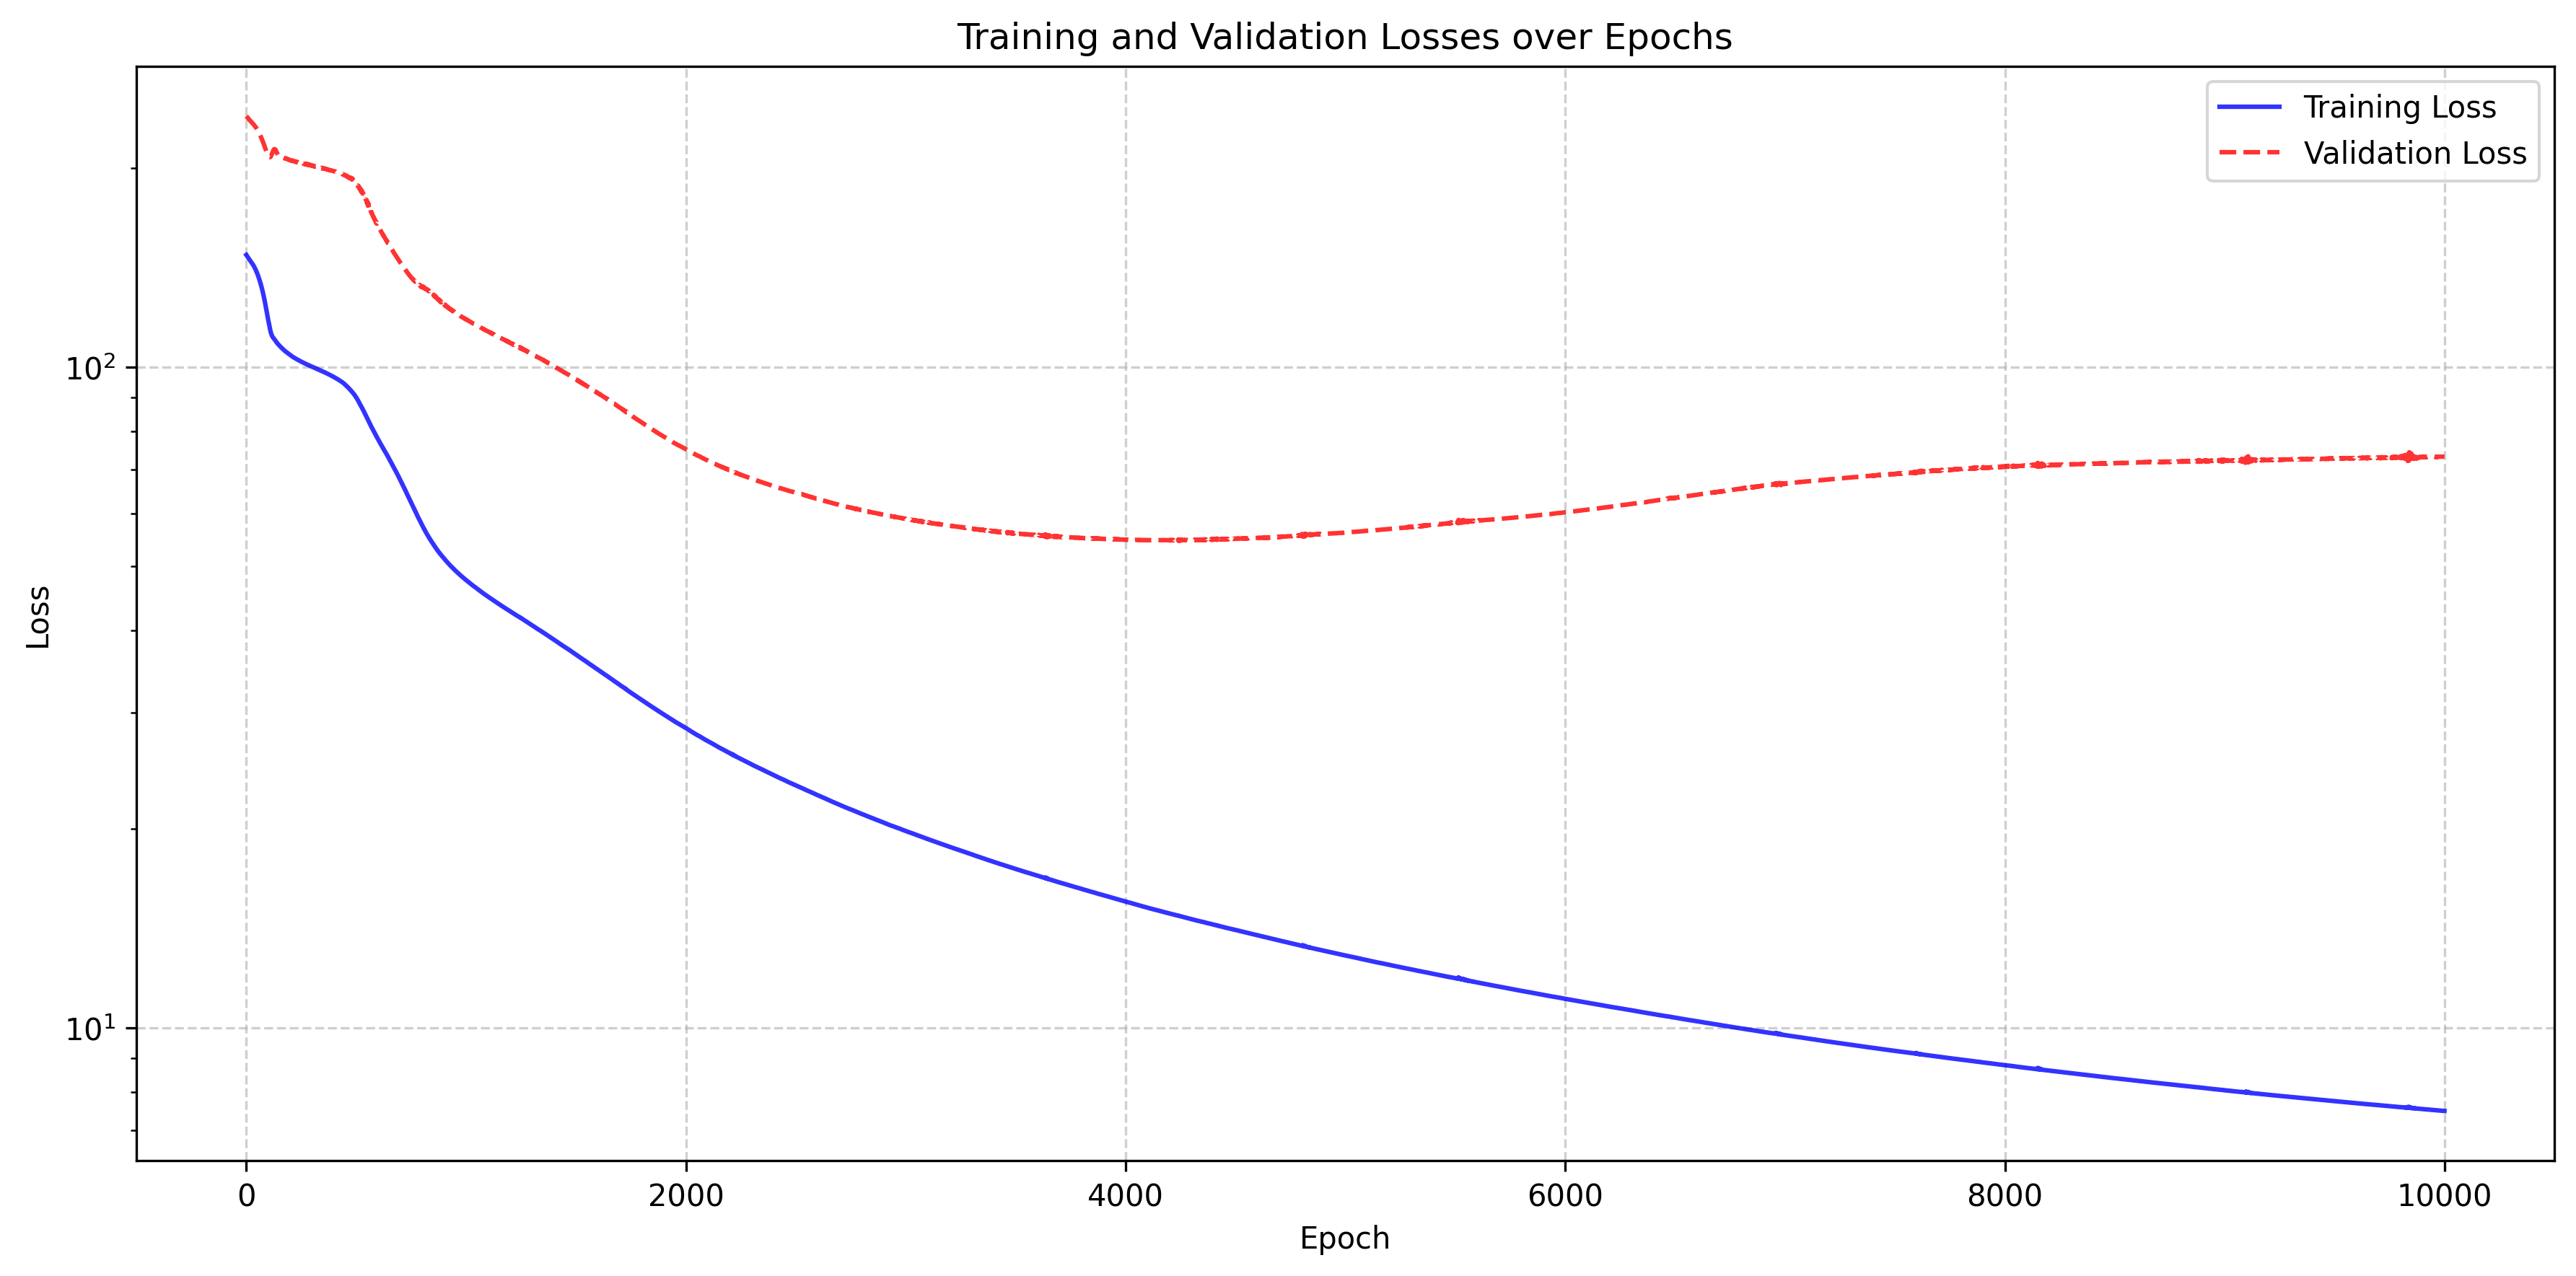

Trainloss: 14.7903, Valloss: 54.6166


In [59]:
################################## Cell 18: Final retraining or Model training ####################################

arch_tag = f"{inputs_num}_{nh}_{outputs_num}" #CHOOSE AICc or Valloss
#arch_tag = f"{inputs_num}_{nh}_{outputs_num}"
print(arch_tag)

final_fold_models = []



model = FFNN(
    input_dim=inputs_num,
    hidden_layers=nh,
    output_dim=outputs_num,
    activation=activation)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

weight_dropout = weight_dropout_with_precalculated_values(model, weight_dropout_rate)

final_model_name = f"Model_results_{arch_tag}.pt"



predictions, train_loss, val_loss = train_Hyb_pytorch(
    model=model,
    target_data=target_data,
    target_max=target_max,
    t_Data=time_data,
    v_Data=volumes_data,
    optimizer=optimizer,
    n_epochs=epochs,
    train_minibatch_rate=train_minibatch_rate,
    weight_dropout_rate=weight_dropout_rate,
    weight_dropout=weight_dropout,
    trainbatch=trainbatch,
    valbatch=valbatch,
    testbatch=testbatch,
    stds_for_data=stds_for_data,
    controls=controls_sequence,
    model_name=final_model_name)

checkpoint = torch.load(final_model_name)

print(f"Trainloss: {round(train_loss,4)}, Valloss: {round(val_loss,4)}")

final_fold_models.append(final_model_name)


8_[3]_7


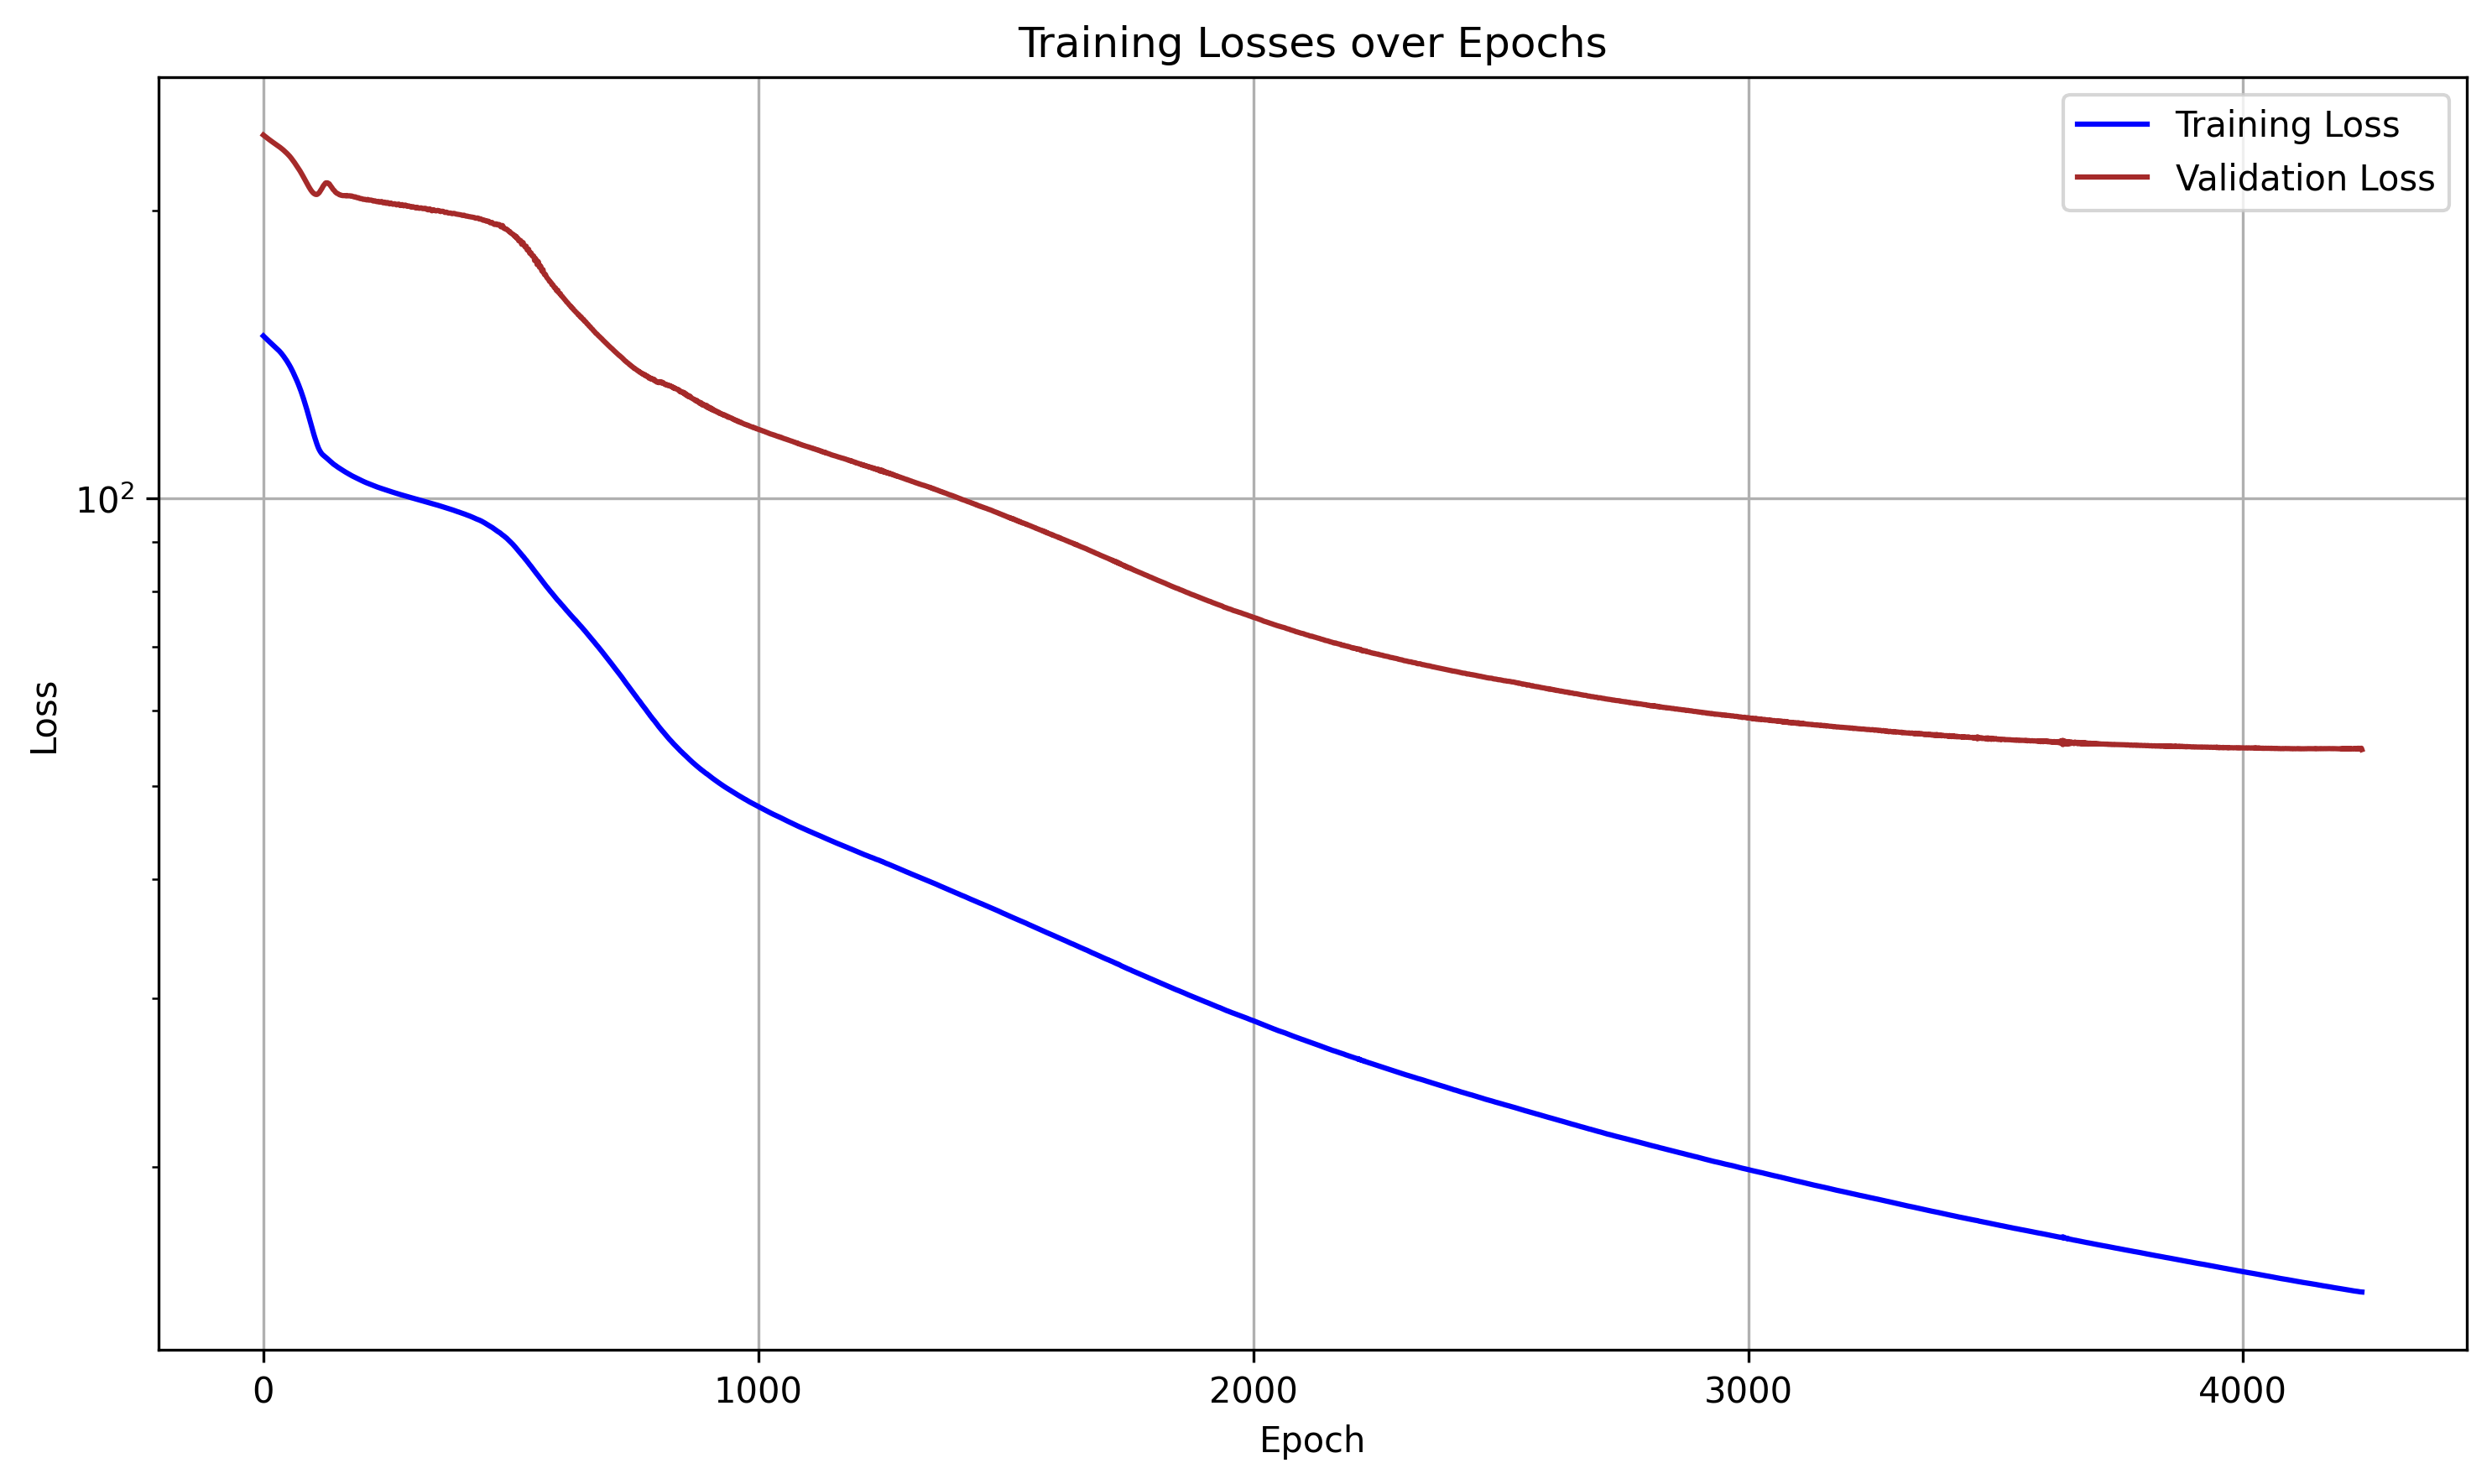

In [60]:
########################## Cell 19: Plot Validation and Training losses ######################

print(arch_tag)

model_name = f"Model_results_{arch_tag}.pt"

model = FFNN(input_dim=inputs_num, hidden_layers=nh, output_dim=outputs_num, activation=activation, activation_output=activation_output)
checkpoint = torch.load(model_name)

trainloss_list = [x.item() if isinstance(x, torch.Tensor) else x for x in checkpoint['trainloss_list']]
valloss_list  = [x.item() if isinstance(x, torch.Tensor) else x for x in checkpoint['valloss_list']]

plt.figure(figsize=(10, 6), dpi=300)
plt.plot(trainloss_list, label="Training Loss", color="blue")
plt.plot(valloss_list, label="Validation Loss", color="brown")
plt.yscale("log")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training Losses over Epochs")
plt.grid()
plt.tight_layout()
plt.show()

In [61]:
################################# Cell 20: Test loss calculation ###############################
#arch_tag = "Adalimumab_26_3_25_1Max_WAIC"
print(arch_tag)

model_path = model_name

def to_float(x):
    return float(x.detach()) if isinstance(x, torch.Tensor) else float(x)

def calculate_ensemble_loss(true_data, t_Data, v_data, compare_data,
                            target_max, controls):

    dim_t = len(t_Data)

    with torch.no_grad():

        y_pred_sum = None


        checkpoint = torch.load(model_path)

        net = FFNN(
            input_dim=inputs_num,
            hidden_layers=nh,
            output_dim=outputs_num,
            activation=activation
        )

        net.load_state_dict(checkpoint["model_state_dict"])
        net.eval()

        state_with_v = torch.cat((true_data[compare_data, 0, :],
                                  v_data[compare_data, 0, :]), dim=1)

        preds = []

        for i in range(dim_t - 1):

            state_with_v = solve_ode_semi_parametric(
                ode_func=solve_ode,
                state=state_with_v,
                model=net,
                target_max=target_max,
                controls=controls[compare_data, i, :],
                t=t_Data[i],
                tf=t_Data[i+1],
                h=TAU
            )

            preds.append(state_with_v[:, :len_species])

            preds = torch.stack(preds)  # (time-1, batch, species)

            y_pred_sum = preds if y_pred_sum is None else (y_pred_sum + preds)

        #average predictions
        y_pred_avg = y_pred_sum / 1
        y_true = []
        testloss = 0

        ######################## Compute errors for average predictions ######################

        # build true values
        for i in range(dim_t - 1):
            y_true.append(true_data[compare_data, i+1])

            testloss += WMSE(
                target_data=y_true[i],
                predicted_data=y_pred_avg[i],
                stds_for_data=stds_for_data[compare_data, i+1]
            )

        y_true = torch.cat(y_true, dim=0)
        y_pred = y_pred_avg.reshape(-1, y_pred_avg.shape[-1])

        y_true_np = y_true.detach().cpu().numpy() / target_max
        y_pred_np = y_pred.detach().cpu().numpy() / target_max

        test_r2 = r2_score(y_true_np.reshape(-1), y_pred_np.reshape(-1))

        testloss = testloss / (dim_t - 1)

    return testloss, test_r2


###################################### Calculate per fold results  ###############################



model = FFNN(
    input_dim=inputs_num,
    hidden_layers=nh,
    output_dim=outputs_num,
    activation=activation
)

checkpoint = torch.load(model_path)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

with torch.no_grad():
    if testbatch !=[]:
        test_loss, test_r2 = calculate_test_loss(
            model=model,
            true_data=target_data,
            t_Data=time_data,
            v_data=volumes_data,
            compare_data=testbatch,
            species_max=species_max,
            controls=controls_sequence
        )

    best_train_loss, train_r2 = calculate_test_loss(
        model=model,
        true_data=target_data,
        t_Data=time_data,
        v_data=volumes_data,
        compare_data=trainbatch,
        species_max=species_max,
        controls=controls_sequence
    )

    if len(valbatch) > 0:
        best_val_loss, val_r2 = calculate_test_loss(
            model=model,
            true_data=target_data,
            t_Data=time_data,
            v_data=volumes_data,
            compare_data=valbatch,
            species_max=species_max,
            controls=controls_sequence
        )

    else:
        best_val_loss = np.nan
        val_r2 = np.nan




8_[3]_7


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/utils.py:3895: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return node.target(*args, **kwargs)  # type: ignore[operator]
/usr/local/lib/python3.13/dist-packages/torch/fx/interpreter.py:380: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return target(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/fx/experimental/proxy_tensor.py:1654: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


y_true_np torch.Size([30, 7])
y_pred_np torch.Size([30, 7])


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/utils.py:3895: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return node.target(*args, **kwargs)  # type: ignore[operator]
/usr/local/lib/python3.13/dist-packages/torch/fx/interpreter.py:380: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return target(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/fx/experimental/proxy_tensor.py:1654: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/utils.py

y_true_np torch.Size([15, 7])
y_pred_np torch.Size([15, 7])
y_true_np torch.Size([90, 7])
y_pred_np torch.Size([90, 7])


In [62]:
############################### Cell 21: Parity Plot ######################################

################################ Build model paths by name, not by relying on final_fold_models in memory ################################

models_paths = [f"Model_results_{arch_tag}.pt"]

@torch.compile(fullgraph=False)
def get_ensemble_predictions_for_batches(models_paths, target_data, t_Data, v_data, batches,
                                         target_max, controls):

    dim_t = len(t_Data)
    n_models = len(models_paths)

    measured_list = []
    pred_sum = None

    with torch.no_grad():

        ######################## Ensemble predictions ########################

        checkpoint = torch.load(model_path)

        net = FFNN(
            input_dim=inputs_num,
            hidden_layers=nh,
            output_dim=outputs_num,
            activation=activation )

        net.load_state_dict(checkpoint["model_state_dict"])
        net.eval()

        state_with_v = torch.cat(
            (target_data[batches, 0, :],
              v_data[batches, 0, :]), dim=1)

        preds = []

        for i in range(dim_t - 1):

            state_with_v = solve_ode_semi_parametric(
                ode_func=solve_ode,
                state=state_with_v,
                model=net,
                target_max=target_max,
                controls=controls[batches, i, :],
                t=t_Data[i],
                tf=t_Data[i+1],
                h=TAU)

            preds.append((state_with_v[:, :len_species] / species_max).cpu().numpy())

        preds = np.array(preds)  # (time-1, batch, species)

        pred_sum = preds if pred_sum is None else (pred_sum + preds)

        pred_avg = pred_sum

        ######################## Measured values ########################
        for i in range(dim_t - 1):
            meas = (target_data[batches, i+1] / species_max).numpy()
            measured_list.append(meas)

        measured_arr = np.array(measured_list)

    return measured_arr, pred_avg



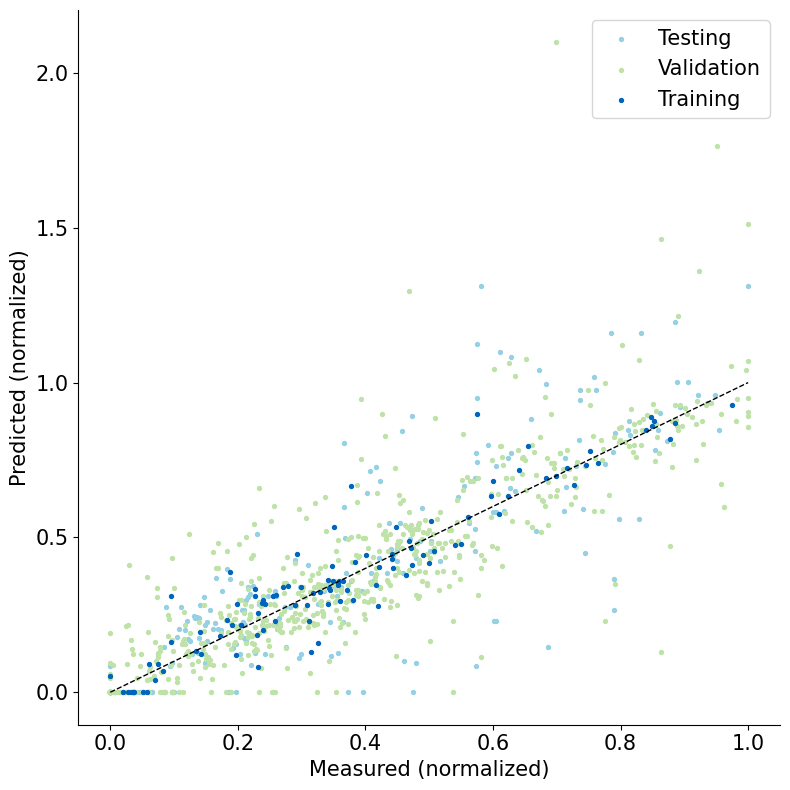

In [63]:
############################### Cell 22: Parity Plot ######################################


trainval_batches = [b for b in batch_numbers if b not in testbatch]

#get train predictions
train_meas, train_pred = get_ensemble_predictions_for_batches(
    models_paths=models_paths,
    target_data=target_data,
    t_Data=time_data,
    v_data=volumes_data,
    batches=trainbatch,
    target_max=target_max,
    controls=controls_sequence
)
#get val predictions
val_meas, val_pred = get_ensemble_predictions_for_batches(
    models_paths=models_paths,
    target_data=target_data,
    t_Data=time_data,
    v_data=volumes_data,
    batches=valbatch,
    target_max=target_max,
    controls=controls_sequence
)

#get test predictions
test_meas, test_pred = get_ensemble_predictions_for_batches(
    models_paths=models_paths,
    target_data=target_data,
    t_Data=time_data,
    v_data=volumes_data,
    batches=testbatch,
    target_max=target_max,
    controls=controls_sequence
)

train_color = "#0065BD"
test_color  = "#95D1E2"
val_color = "#BFE2A8"

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(test_meas.reshape(-1), test_pred.reshape(-1), s=8, alpha=1, color=test_color, label='Testing', zorder=1)
ax.scatter(val_meas.reshape(-1), val_pred.reshape(-1), s=8, alpha=1, color=val_color, label='Validation', zorder=2)
ax.scatter(train_meas.reshape(-1), train_pred.reshape(-1), s=8, alpha=1, color=train_color, label='Training', zorder=3)

#parity line only
ax.plot([0, 1], [0, 1], 'k--', lw=1.0, zorder=3)

ax.set_xlabel("Measured (normalized)", fontsize=15)
ax.set_ylabel("Predicted (normalized)", fontsize=15)
ax.tick_params(axis='both', labelsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=15)

plt.tight_layout()
plt.show()



In [64]:
################################################ Cell 23: True vs Predicted, True vs Noisy ################################

########################################################## Prepare True Data ##############################################
print(arch_tag)
print()

#full model batch indices
trainval_batches = [b for b in batch_numbers if b not in testbatch]

model_path = f"Model_results_{arch_tag}.pt"

@torch.compile(fullgraph=False)
def calculate_metrics_vs_true(true_data, compare_data, stds_for_data, batches):

    testloss, test_r2 = 0, 0
    dim_t = true_data.shape[1]

    y_true = []
    y_pred = []

    with torch.no_grad():
        #loop ODE system over time points to get predictions
        for i in range(dim_t - 1):

            #calculate test loss and r2, summing over time
            testloss += WMSE(
                target_data=true_data[batches, i+1],
                predicted_data=compare_data[batches, i+1],
                stds_for_data=stds_for_data[batches, i+1])

            #append measured values (no volume)
            y_true.append(true_data[batches, i+1])
            #append predicted values (no volume)
            y_pred.append(compare_data[batches, i+1])

    y_true = torch.cat(y_true, dim=0)
    y_pred = torch.cat(y_pred, dim=0)
    y_true_np = y_true.detach().cpu().numpy() / species_max
    y_pred_np = y_pred.detach().cpu().numpy() / species_max
    test_r2 = r2_score(y_true_np.reshape(-1), y_pred_np.reshape(-1))
    testloss = testloss / (dim_t - 1)

    return testloss, test_r2

################################# Noisy vs True #######################################

#for training and validation
noisy_vs_true_trainval_wmse, noisy_vs_true_trainval_r2 = calculate_metrics_vs_true(
    true_data=true_data,
    compare_data=target_data,
    stds_for_data=stds_for_data,
    batches=trainval_batches)

#for testing
if testbatch != []:
    noisy_vs_true_test_wmse, noisy_vs_true_test_r2 = calculate_metrics_vs_true(
        true_data=true_data,
        compare_data=target_data,
        stds_for_data=stds_for_data,
        batches=testbatch)

################################# Predicted vs True ####################################

#TRAIN+VAL predictions (ensemble)
meas_trainval, pred_trainval = get_ensemble_predictions_for_batches(
    models_paths=models_paths,
    target_data=target_data,
    t_Data=time_data,
    v_data=volumes_data,
    batches=trainval_batches,
    target_max=target_max,
    controls=controls_sequence
)

pred_trainval = torch.from_numpy(pred_trainval) * species_max

pred_full_trainval = true_data.clone()
for j, b in enumerate(trainval_batches):
    pred_full_trainval[b, 1:, :] = pred_trainval[:, j, :]


#TEST predictions (ensemble)
if testbatch != []:
    meas_test, pred_test = get_ensemble_predictions_for_batches(
        models_paths=models_paths,
        target_data=target_data,
        t_Data=time_data,
        v_data=volumes_data,
        batches=testbatch,
        target_max=target_max,
        controls=controls_sequence
    )

    pred_test = torch.from_numpy(pred_test) * species_max

    pred_full_test = true_data.clone()
    for j, b in enumerate(testbatch):
        pred_full_test[b, 1:, :] = pred_test[:, j, :]

############################################ Metrics ##################################



#train vs Noisy
pred_vs_noisy_train_wmse, pred_vs_noisy_train_r2 = calculate_metrics_vs_true(
    true_data=target_data,
    compare_data=pred_full_trainval,
    stds_for_data=stds_for_data,
    batches=trainbatch
)
#val vs Noisy
pred_vs_noisy_val_wmse, pred_vs_noisy_val_r2 = calculate_metrics_vs_true(
    true_data=target_data,
    compare_data=pred_full_trainval,
    stds_for_data=stds_for_data,
    batches=valbatch
)


#test vs Noisy
if testbatch != []:
    pred_vs_noisy_test_wmse, pred_vs_noisy_test_r2 = calculate_metrics_vs_true(
        true_data=target_data,
        compare_data=pred_full_test,
        stds_for_data=stds_for_data,
        batches=testbatch
    )

#asemble metrics table
records = []

def add_row(dataset, comparison, wmse, r2):
    records.append({
        "Dataset": dataset,
        "Comparison": comparison,
        "WMSE": wmse,
        "R2": r2
    })


#model results
add_row("\nTrain ", "Pred vs Noisy", pred_vs_noisy_train_wmse, pred_vs_noisy_train_r2)
add_row("Val ", "Pred vs Noisy", pred_vs_noisy_val_wmse, pred_vs_noisy_val_r2)
add_row("Test", "Pred vs Noisy", pred_vs_noisy_test_wmse, pred_vs_noisy_test_r2)

header = (f"{'Dataset':<10} | {'Comparison':<15} | {'WMSE':^8} | {'R²':^8}")

#print table
print(header)
print("-" * len(header))

for r in records:
    print(f"{r['Dataset']:<10} | {r['Comparison']:<15} | {r['WMSE']:^8.4f} | {r['R2']:^8.4f}")
#Train+Val  | Pred vs True    |  0.0529  |  0.9551
#Test       | Pred vs True    |  0.0926  |  0.9199
params_model  = sum(p.numel() for p in model.parameters() if p.requires_grad)
params_total = target_data.numel() - target_data[:,0, 0].numel() * target_data[0, 0, :].numel()
AICc = params_total * math.log(pred_vs_noisy_train_wmse) + 2 * params_model + (2 * params_model * (params_model + 1))/(params_total - params_model - 1)
print("AICc", AICc)

8_[3]_7

Dataset    | Comparison      |   WMSE   |    R²   
--------------------------------------------------

Train     | Pred vs Noisy   | 14.7903  |  0.8821 
Val        | Pred vs Noisy   | 54.6166  |  0.6403 
Test       | Pred vs Noisy   | 79.9699  |  0.5274 
AICc 2662.730819716195


/tmp/ipykernel_53303/280196891.py:44: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std_pred  = pred_models.std(dim=0)


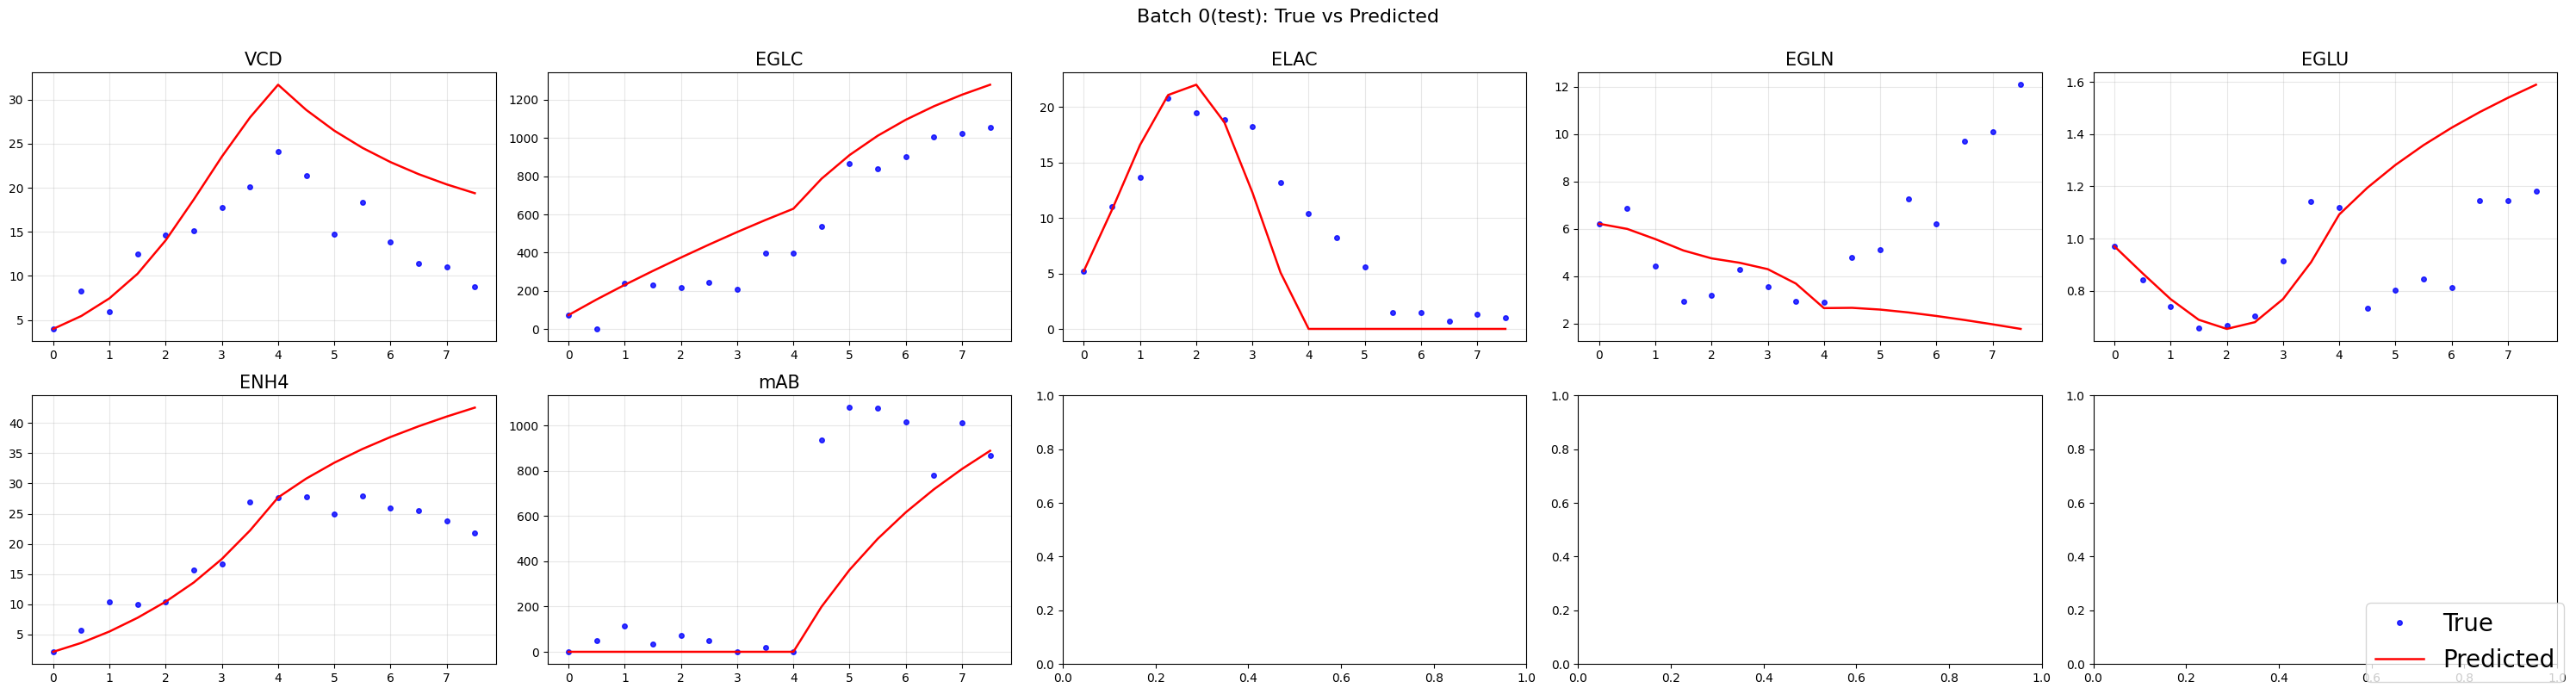

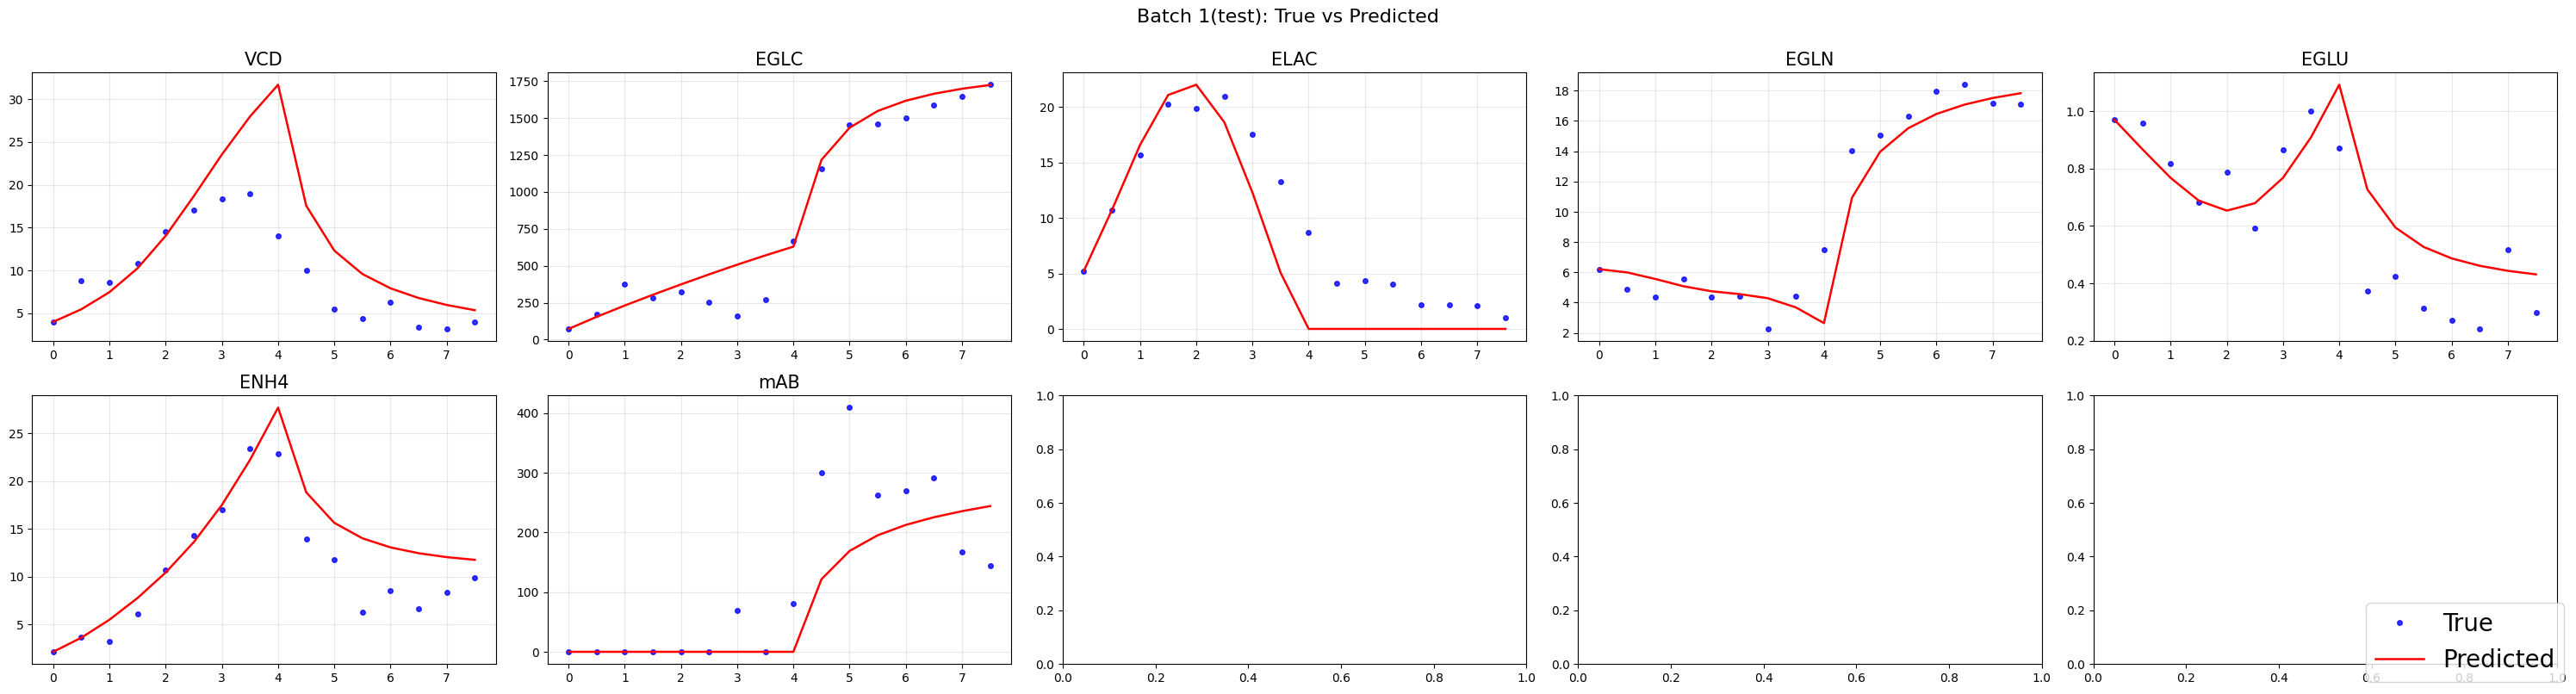

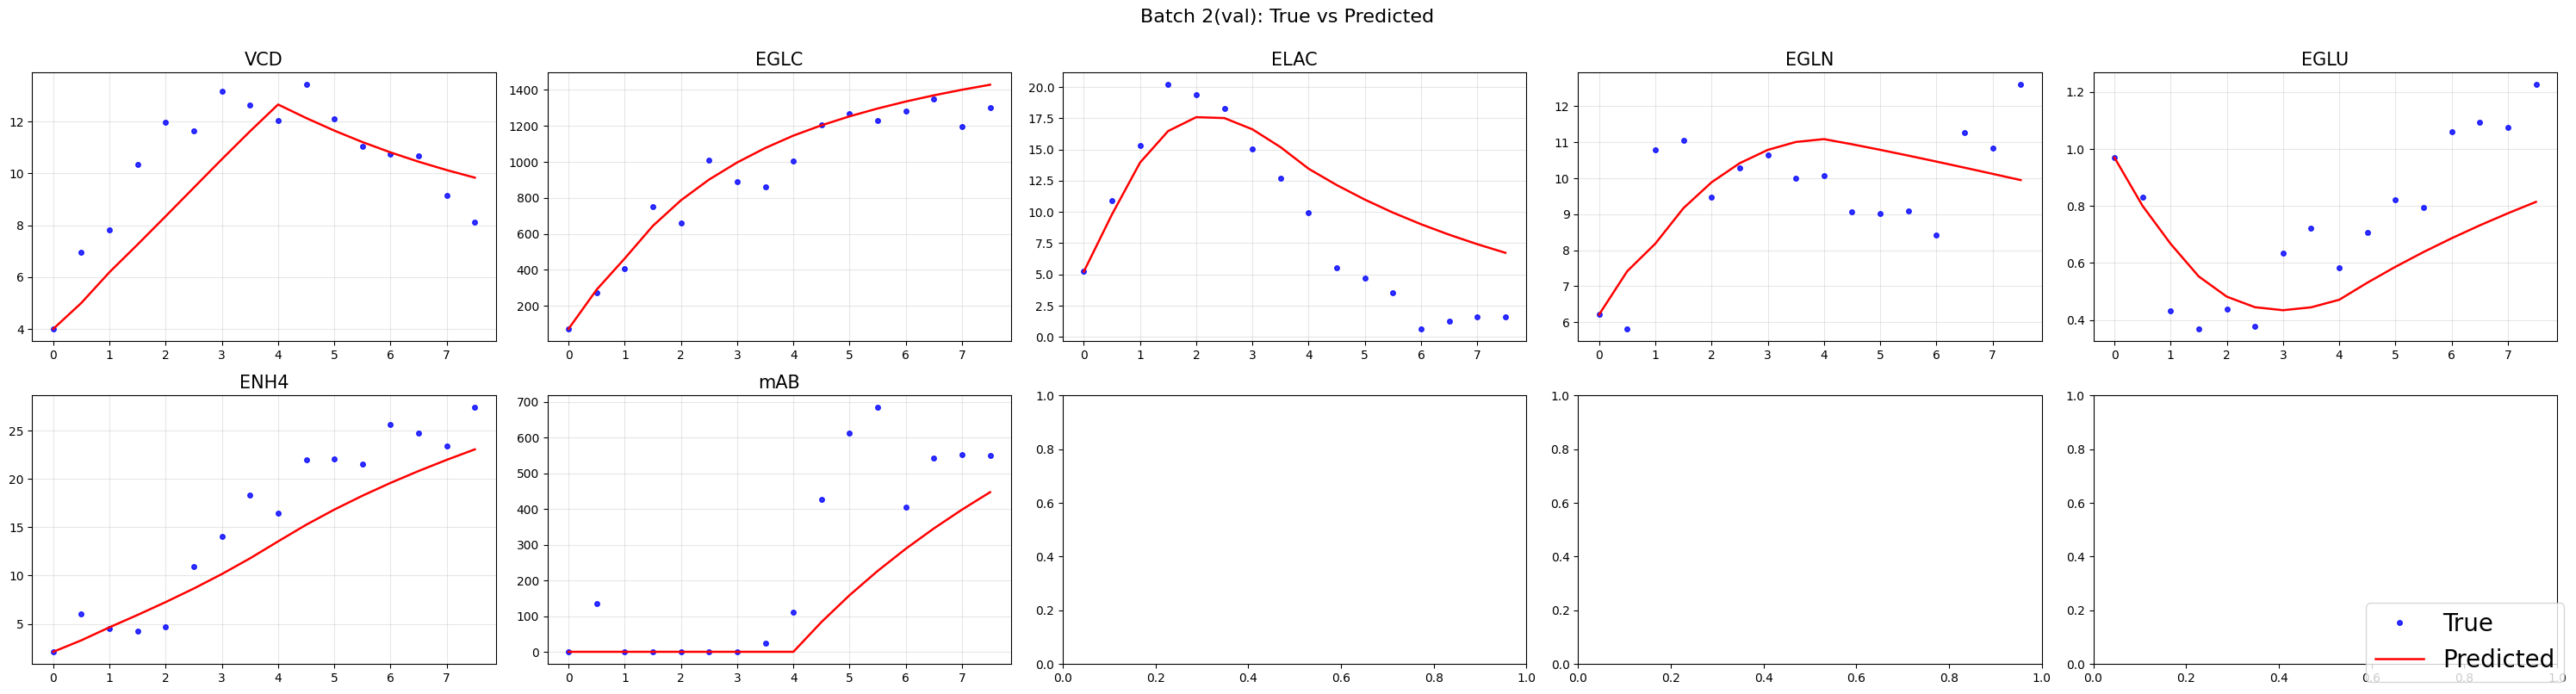

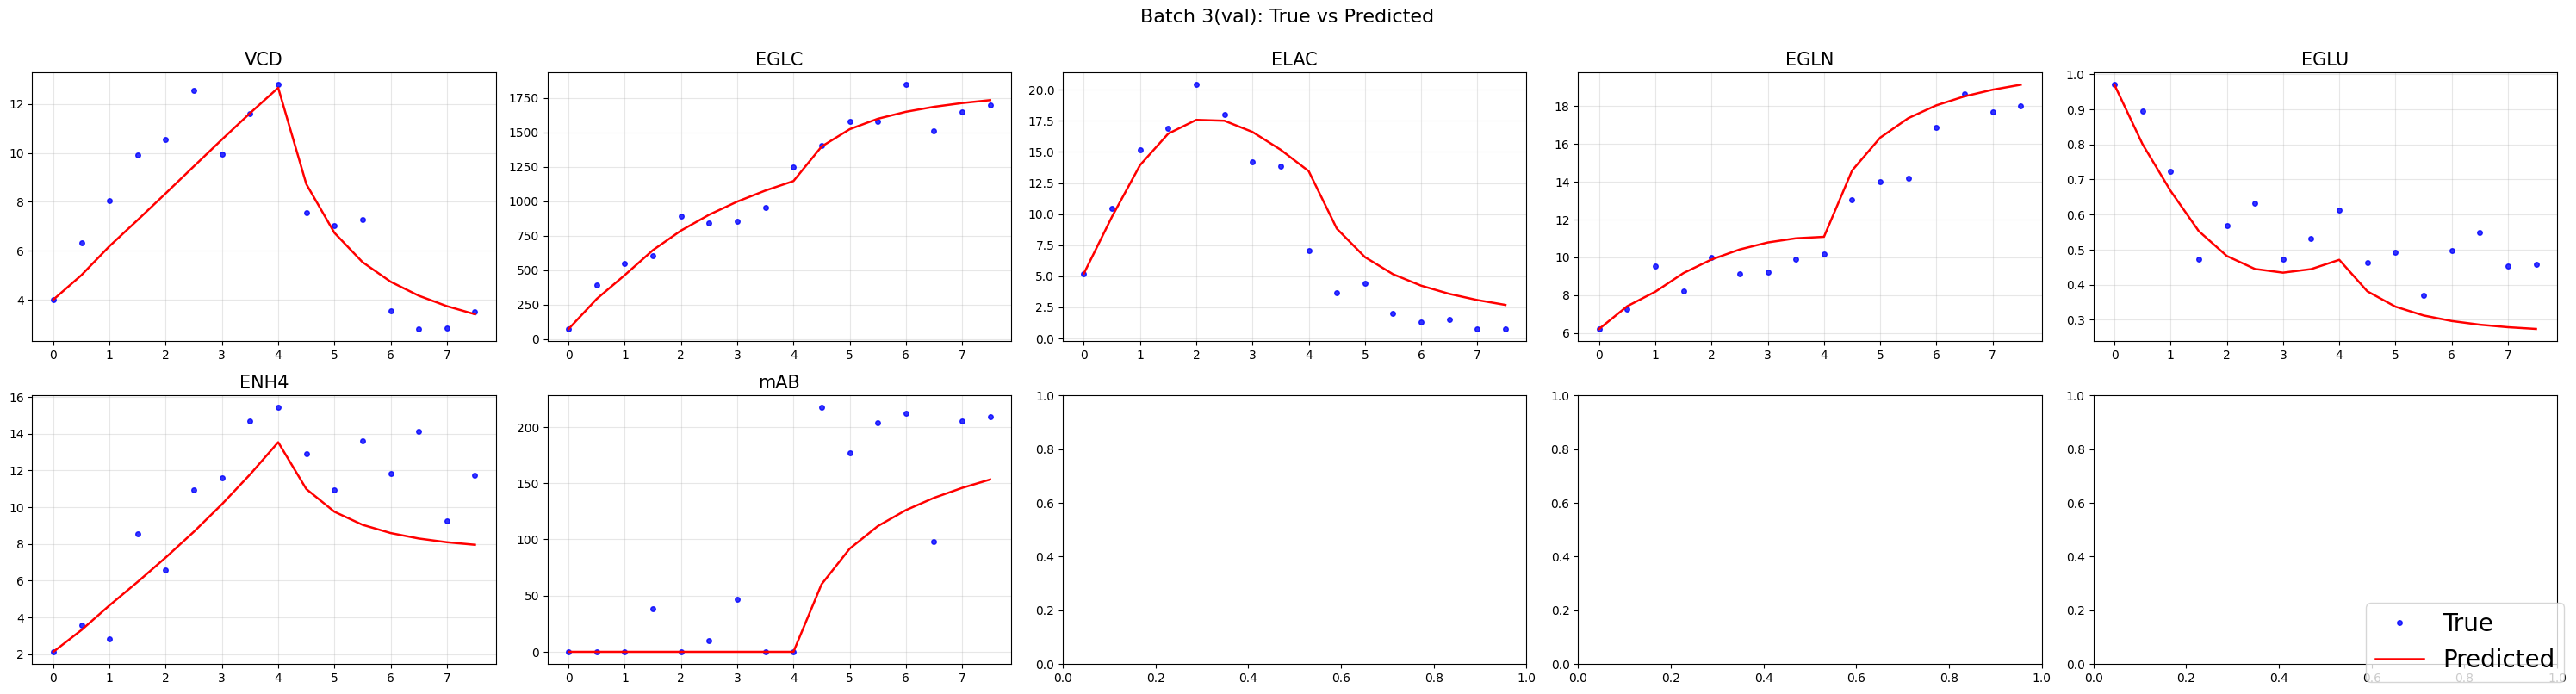

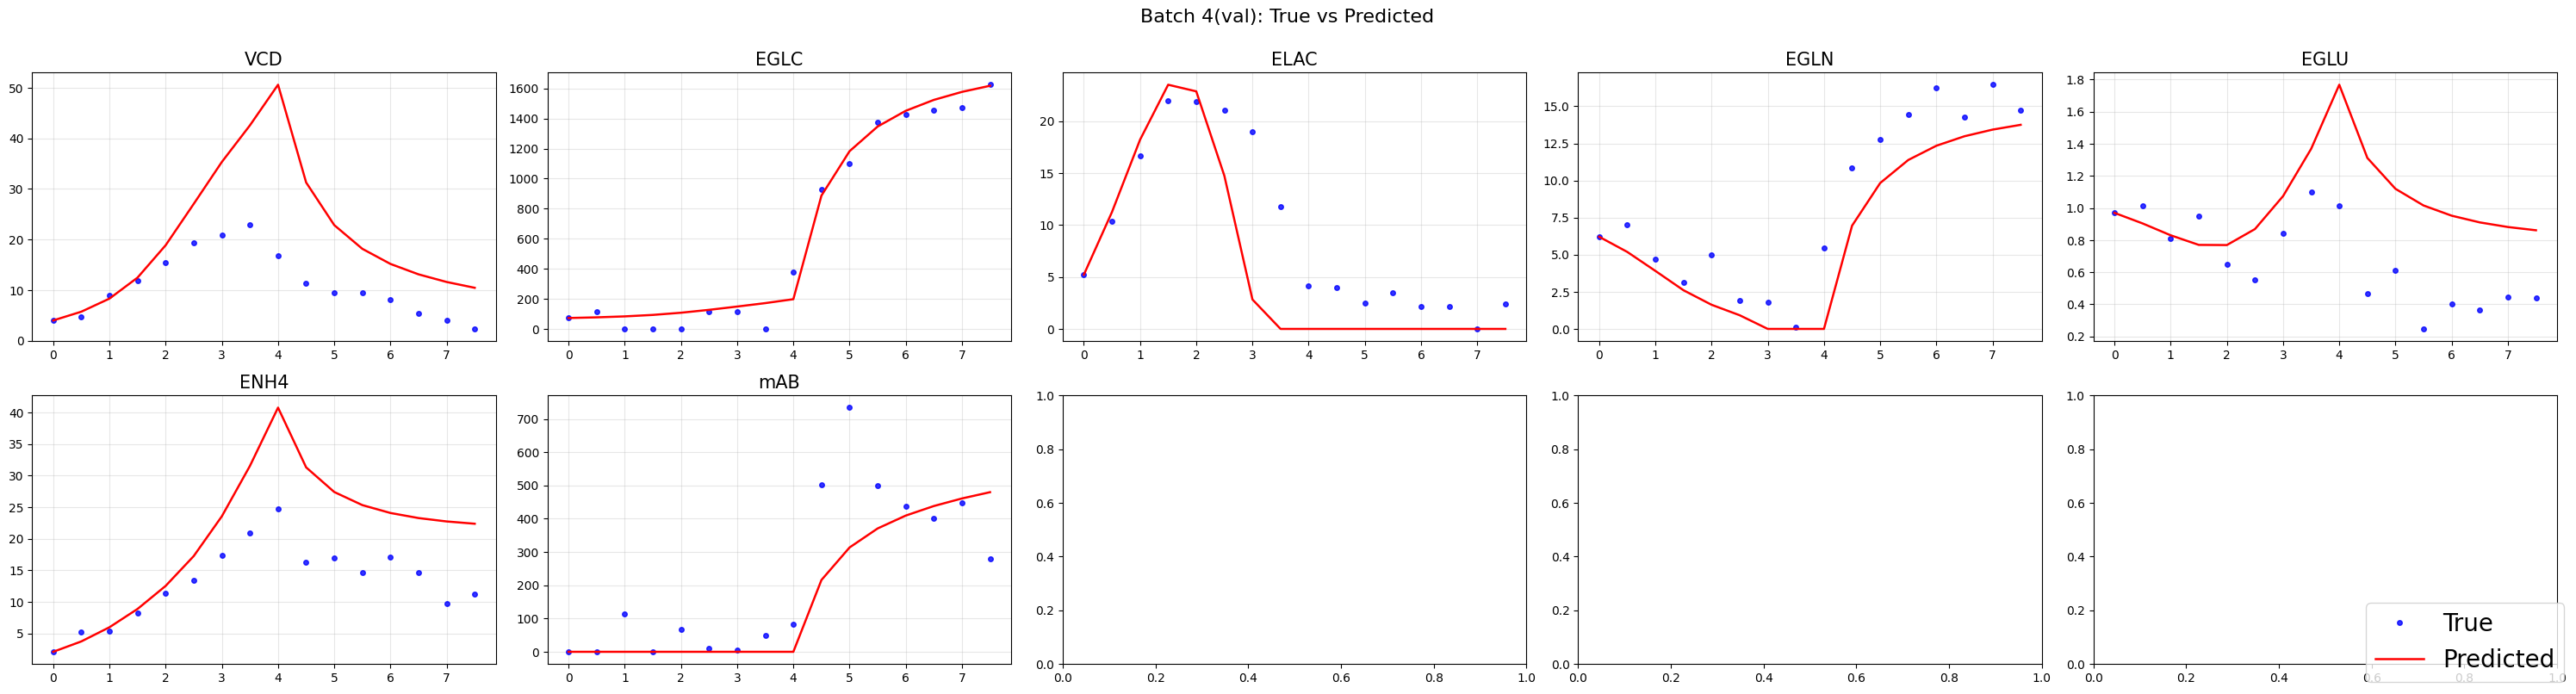

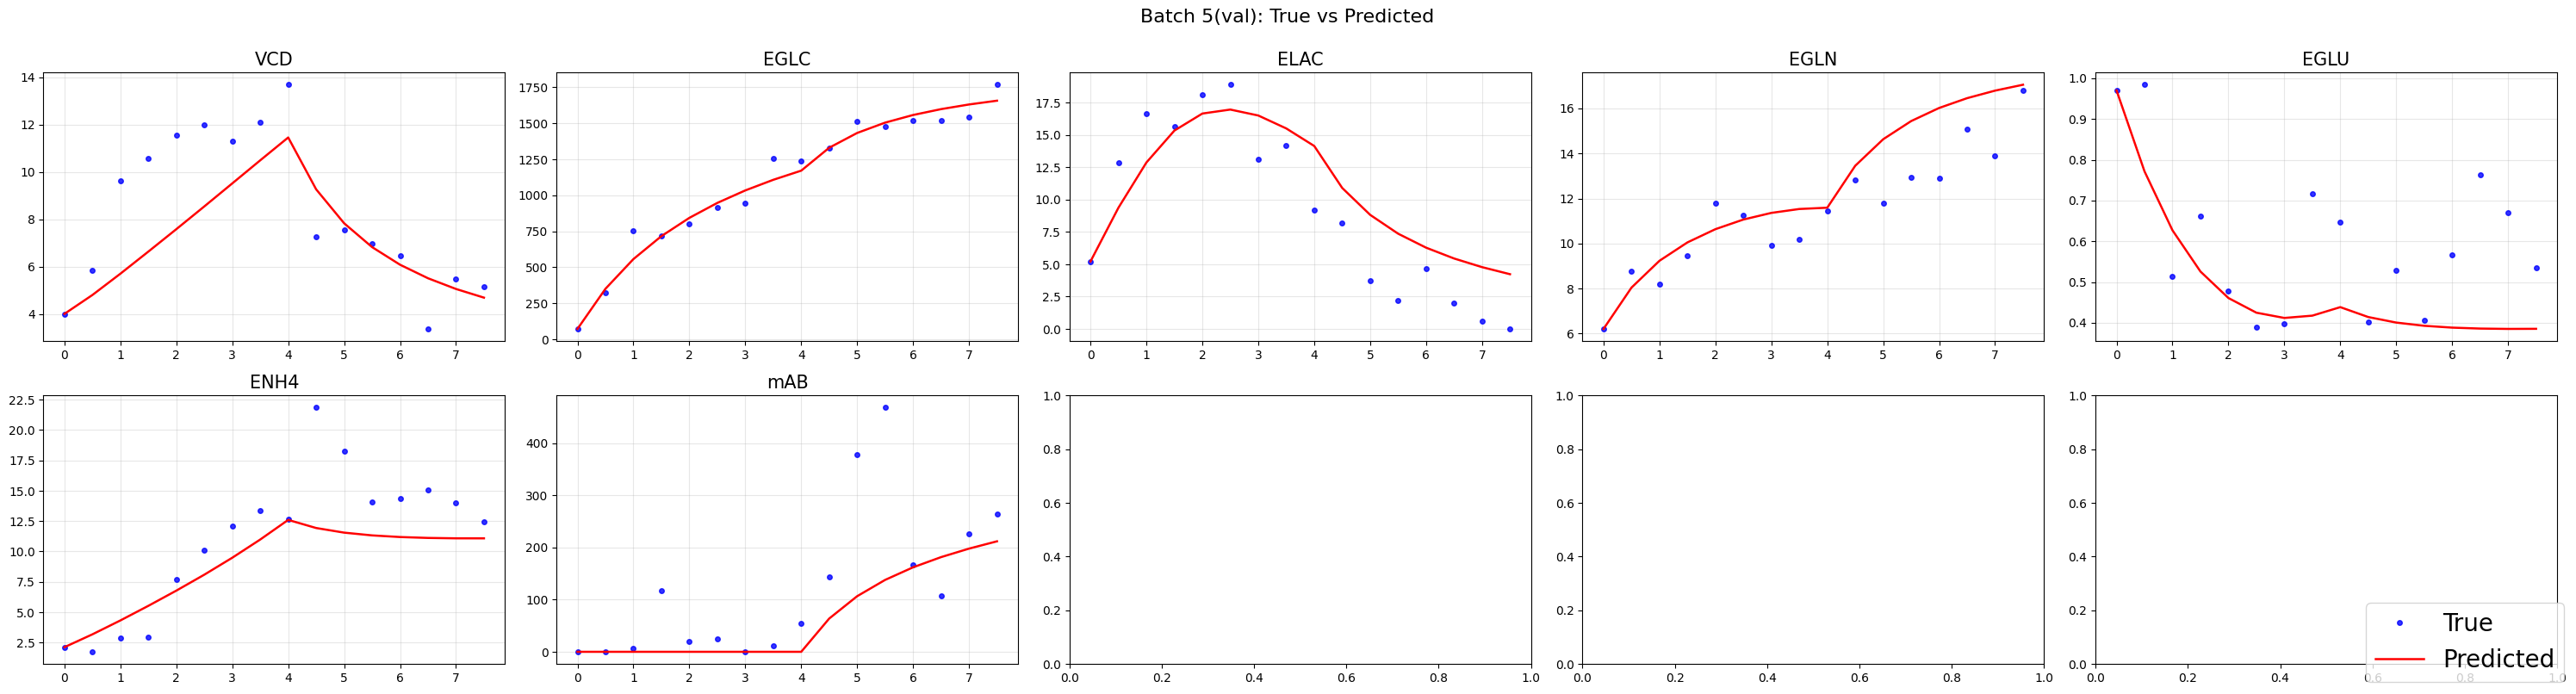

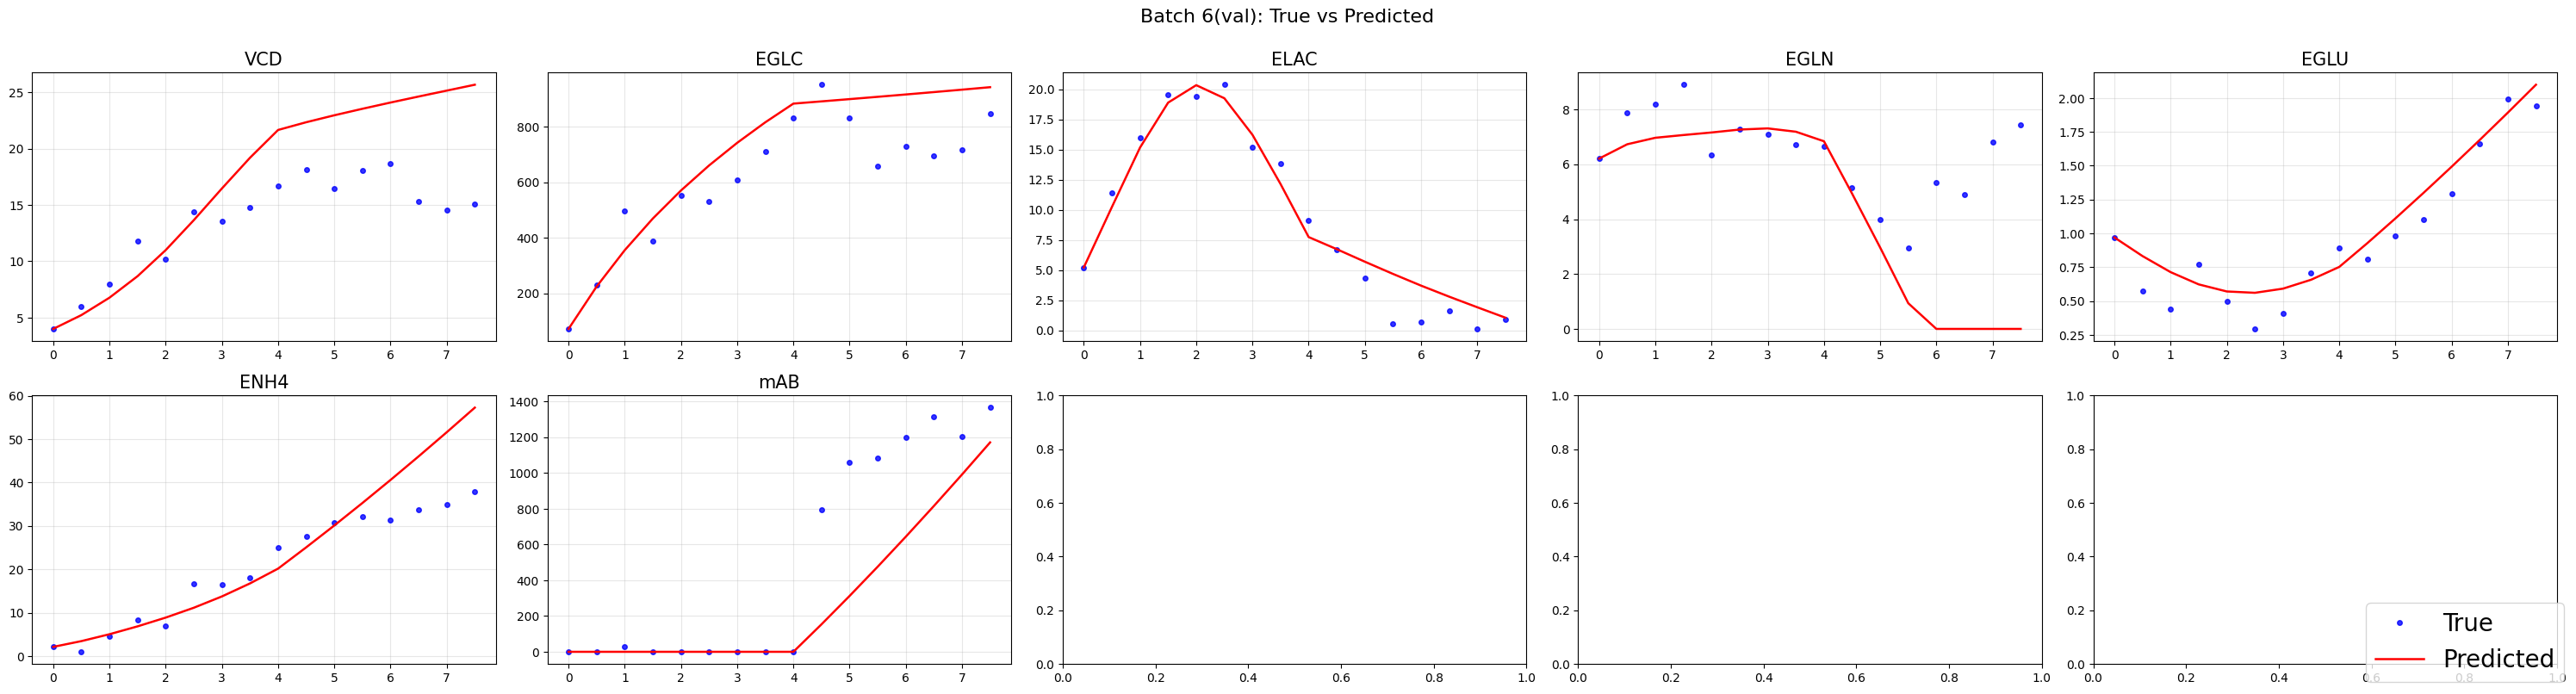

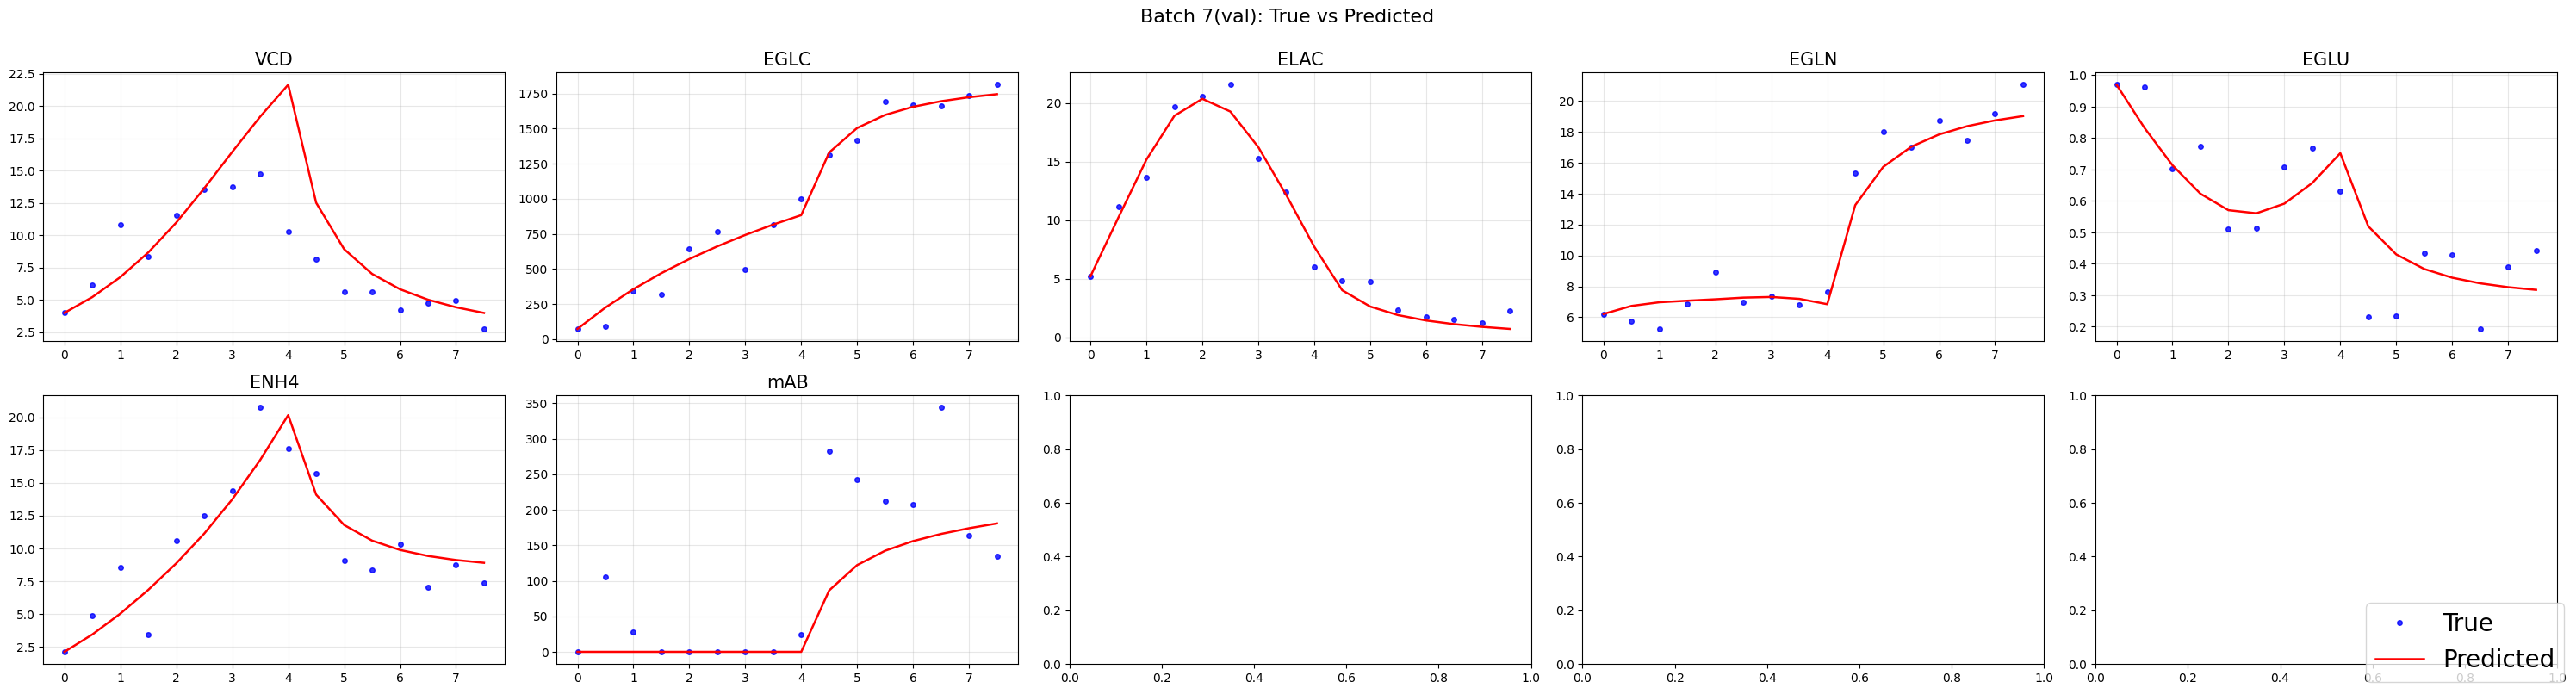

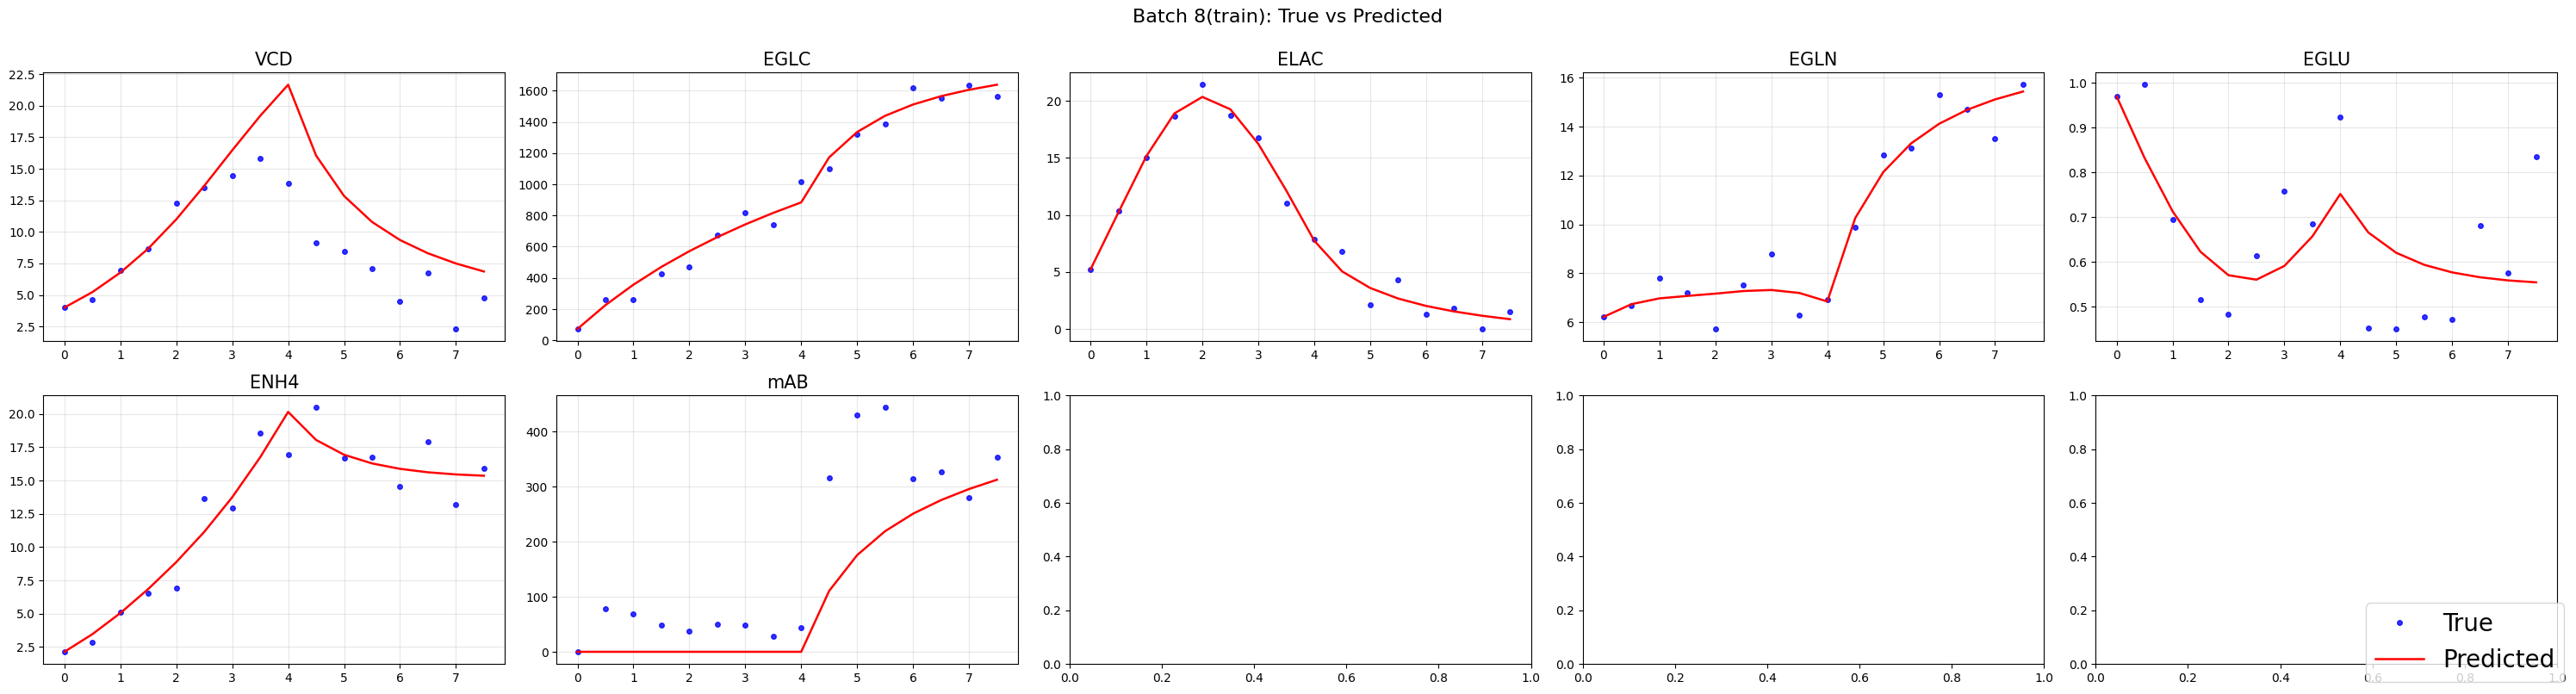

In [65]:
########################## Cell 24: Ensemble Predictions + CI + Plot #############################


all_batches = batch_numbers
checkpoint = torch.load(model_path)
net = FFNN(
    input_dim=inputs_num,
    hidden_layers=nh,
    output_dim=outputs_num,
    activation=activation
)
net.load_state_dict(checkpoint["model_state_dict"])
net.eval()

with torch.no_grad():

    state_with_v = torch.cat((target_data[all_batches, 0, :], volumes_data[all_batches, 0, :]), dim=1)
    preds = []

    for i in range(len(time_data) - 1):
        state_with_v = solve_ode_semi_parametric(
            ode_func=solve_ode,
            state=state_with_v,
            model=net,
            target_max=target_max,
            controls=controls_sequence[all_batches, i, :],
            t=time_data[i],
            tf=time_data[i+1],
            h=TAU
        )

        preds.append(state_with_v[:, :len_species].detach().cpu())

    preds = torch.stack(preds)  # (T-1, B, S)

pred_models = torch.stack([preds])  # (n_models, T-1, B, S)

init = (target_data[all_batches, 0, :]).unsqueeze(0).unsqueeze(0)
init = init.repeat(1, 1, 1, 1)

pred_models = torch.cat([init, pred_models], dim=1)

mean_pred = pred_models.mean(dim=0)   # (T-1, B, S)
std_pred  = pred_models.std(dim=0)

t_value = 0.0

std_error = std_pred

ci_minus = mean_pred - t_value * std_error
ci_plus  = mean_pred + t_value * std_error

title_suffix = f"Ensemble (n=1)"

for batch_idx, b in enumerate(all_batches):

    # TRUE
    true_traj = true_data[b]
    num_species = true_traj.shape[1]

    n_cols = min(5, num_species)
    n_rows = int(np.ceil(num_species / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows), squeeze=False)
    axs = axs.flatten()

    for s in range(num_species):
        ax = axs[s]
        species_label = species_names[s]

        ax.plot(time_data, true_traj[:, s], "o", markersize=4, alpha=0.8, color = "blue", label="True" if s == 0 else None)
        ax.plot(time_data, mean_pred[:, batch_idx, s], color = "red", linewidth=1.8, label="Predicted" if s == 0 else None)

        ax.set_title(species_label, fontsize=15)
        ax.grid(alpha=0.3)
    batch_label = "(train)" if batch_idx in trainbatch else\
      "(test)" if batch_idx in testbatch else\
      "(val)" if batch_idx in valbatch else None
    fig.suptitle(f"Batch {b}{batch_label}: True vs Predicted", fontsize=16, y = 1.0)
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower right", fontsize=20)
    plt.tight_layout()
    plt.show()

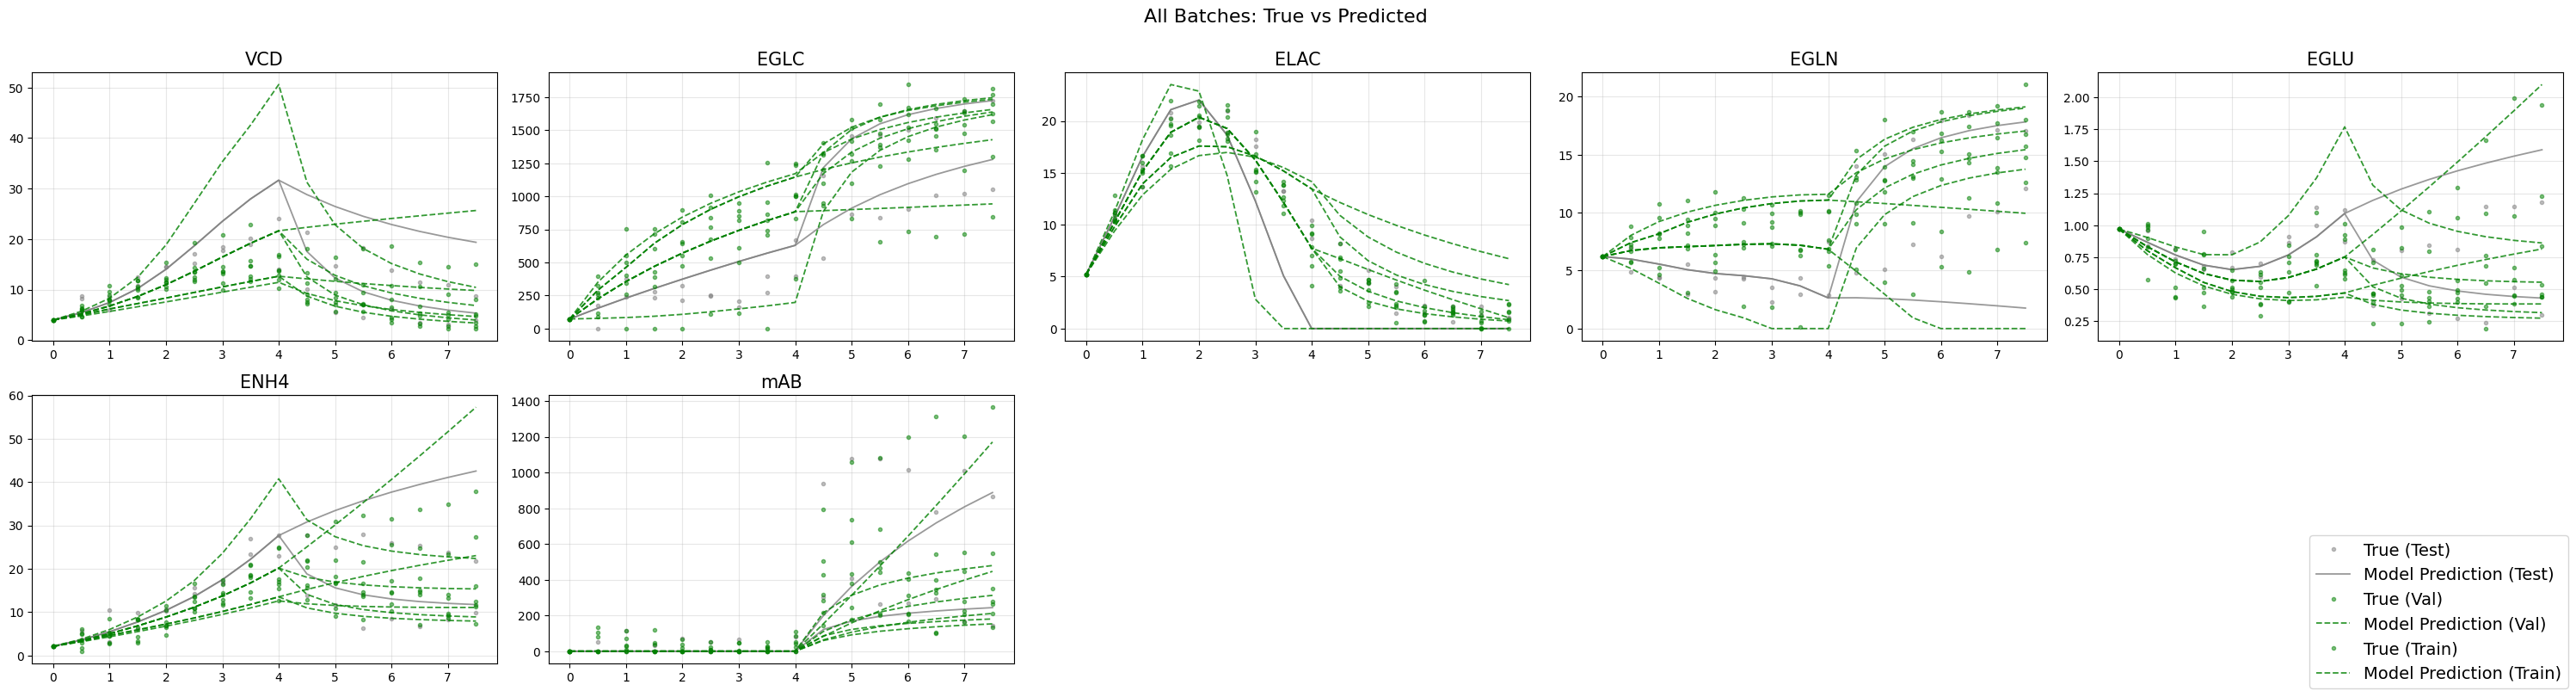

In [66]:
########################## Cell 25 (revised): Single Figure, All Batches, Train/Test Highlighted #############################

num_species = true_data.shape[2]

n_cols = min(5, num_species)
n_rows = int(np.ceil(num_species / n_cols))

# Using squeeze=False ensures that axs is always returned as a 2D numpy array of Axes
fig, axs = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows), squeeze=False)
axs = axs.flatten()

#track which legend labels are already placed, so each appears once
labels_used = set()

for s in range(num_species):
    ax = axs[s]
    species_label = species_names[s]

    for batch_idx, b in enumerate(all_batches):
        is_test = b in testbatch
        is_val = b in valbatch
        is_train = b in trainbatch

        true_color = "grey" if is_test else "green"
        pred_color = "grey" if is_test else "green"
        true_label_key = "True (Test)" if is_test else "True (Train)" if is_train else "True (Val)"
        pred_label_key = "Model Prediction (Test)" if is_test else "Model Prediction (Train)" if is_train else "Model Prediction (Val)"

        true_label = true_label_key if true_label_key not in labels_used else None
        pred_label = pred_label_key if pred_label_key not in labels_used else None
        labels_used.add(true_label_key)
        labels_used.add(pred_label_key)

        ax.plot(time_data, true_data[b, :, s], "o", markersize=3, alpha=0.5,
                color=true_color, label=true_label)
        ax.plot(time_data, mean_pred[:, batch_idx, s], "--" if not is_test else "-", color=pred_color,
                linewidth=1.3, alpha=0.8, label=pred_label)


    ax.set_title(species_label, fontsize=15)
    ax.grid(alpha=0.3)

for k in range(num_species, n_rows*n_cols):
    fig.delaxes(axs[k])

fig.suptitle(f"All Batches: True vs Predicted", fontsize=16, y=1.0)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=14)
plt.tight_layout()
plt.show()